# Predicting ICU trajectories and outcomes from the first 48 hours

**MD6117 Machine Learning for Healthcare AI: group project notebook**

Both tasks use the **PhysioNet/Computing in Cardiology Challenge 2012** data: 12,000 adult ICU stays of at least 48 hours, with irregularly sampled vitals and labs (`data/README.md` describes the dataset).

| | **Task 1: SOFA Trajectory Forecasting** | **Task 2: In-Hospital Mortality Prediction** |
|---|---|---|
| **Task focus** | *6-hour-ahead forecast of the rolling 24-hour rule-based proxy-SOFA score* | *In-hospital mortality prediction from the first 48 hours after ICU admission* |
| **Question** | At T = 24, 30, 36, or 42 h, what will the proxy-SOFA over [T-18, T+6) be, using only measurements available before T? | At the 48-h prediction point, can measurements from [0, 48 h) predict death before hospital discharge, including after ICU discharge? |
| **Prediction time** | *T* ∈ {24, 30, 36, 42} h | 48 h |
| **Inputs** | everything measured before *T* | everything measured in [0, 48) h |
| **Output** | six organ proxy-SOFA sub-scores and total `sofa_24h_tplus6`; binary label `sofa_rise_ge2_tplus6` indicating a ≥2-point rise from baseline | P(in-hospital death) |
| **Unit / n** | stay × decision time, 48,000 rows (12,000 stays) | stay, 12,000 rows |
| **Bar to beat** | persistence ("nothing changes") | bedside scores (SAPS-I, SOFA) and a ladder of simpler models |
| **Primary metric** | MAE (bootstrap 95 % CI) | AUPRC, plus AUROC (bootstrap 95 % CI) |

**How the data are prepared.** Both tasks follow the same rules:

1. **Split first.** Each split is made at stay level before any statistic is computed.
2. **Pre-processing.** Cleaning, outlier screening, time-window aggregation and feature engineering.
3. **Models as pipelines.** Every model is a single scikit-learn / imbalanced-learn `Pipeline`. In order, it applies:
   1. filter-type feature selection;
   2. imputation, encoding and scaling, where the model needs them;
   3. an optional resampling step for class imbalance;
   4. the estimator.

   Each step is fitted on training rows only, inside each cross-validation fold during development, and the fitted pipeline is what gets saved.
4. **Choices made without test.** Class-imbalance strategy, hyperparameters and feature subsets are chosen on train or validation, and the test set is scored once.
5. **One seed.** All randomness is seeded from a single constant (next cell).

**How to run.** Run all cells top to bottom from the repository root; `README.md` lists the environment. The switches in the next cell control what is recomputed.

**How the outputs below were produced.** Every model was fitted by this notebook's own cells, in two executions (split only because of run time):

1. A first execution with `RETRAIN_TASK1 = True` fitted and saved all task 1 pipelines, about 1 h 40 min on a laptop CPU. It wrote the training outputs (grids, imbalance experiment, filter check) to `trained_models/task1_sofa/model_spec.json`.
2. The execution shown here uses `RETRAIN_TASK1 = False`, so it *loads* those pipelines and reprints their logged training tables. It uses `RETRAIN_TASK2 = False`, so task 2 loads the saved experiments and fitted pipelines; set it to `True` only to repeat the long model searches and fits.

**Contents.**

* *Part A (Task 1):* A1 objective & problem · A2 data & cleaning · A3 rule-based SOFA engine · A4 targets · A5 split · **A6 pre-processing & feature engineering** · **A7 feature selection** · A8 baselines · A9 methods & pipelines · A10 training (incl. class imbalance) · A11 results · A12 interpretation · A13 discussion.
* *Part B (Task 2):* B1 problem · **B2 pre-processing** · **B3 feature engineering** · **B4 pipelines, leakage control & feature filter** · B5 baseline ladder (incl. class imbalance) · **B6 L4: imbalance, tuning & embedded feature selection** · B7 test evaluation · B8 calibration & subgroups · B9 interpretation · B10 challenge metric · B11 discussion.
* *Part C:* summary and saved artefacts.

In [1]:
# ---- run switches ---------------------------------------------------------------------
REBUILD_PREPROCESSING = False  # True: rebuild preprocessed/ from data/icu_records (task 1 ~4 min, task 2 ~10 min)
RETRAIN_TASK1 = False          # True: refit every task 1 pipeline (~1 h 40 min, CPU). False: load the pipelines
                               #       the A10 cells fitted and saved in trained_models/task1_sofa/
RETRAIN_TASK2 = False           # False: load the logged experiments and fitted pipelines in trained_models/task2_mortality/.
                               # True reruns the imbalance CV, the 50 x 5-fold XGBoost search, nested-CV feature
                               # selection and the final fits (~40 min; uses a CUDA GPU for XGBoost when available)

# ---- environment ------------------------------------------------------------------------
import os, sys, io, json, time, warnings, contextlib
from pathlib import Path
from functools import reduce

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*Falling back to prediction using DMatrix.*")

import numpy as np
import pandas as pd
import joblib
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.precision", 3)
pd.set_option("display.float_format", lambda v: f"{v:.4f}".rstrip("0").rstrip(".") if abs(v) < 1e6 else f"{v:.3g}")

import sklearn, imblearn, xgboost, catboost, lightgbm, shap
print("python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| imbalanced-learn", imblearn.__version__,
      "| xgboost", xgboost.__version__, "| catboost", catboost.__version__,
      "| lightgbm", lightgbm.__version__, "| shap", shap.__version__)
print("repo root:", ROOT)

python 3.13.1 | numpy 2.3.4 | pandas 2.3.3 | scikit-learn 1.7.2 | imbalanced-learn 0.14.2 | xgboost 3.4.1 | catboost 1.2.10 | lightgbm 4.7.0 | shap 0.52.0
repo root: C:\Users\pan shengxin\Downloads\release\release\healthcare-ai-assin


### Reproducibility: one seed everywhere

The assignment requires reproducible results, so every source of randomness is seeded from one constant, `SEED = 42` (`src/shared/reproducibility.py`). The only other seed is task 2's frozen data split (20260907). The table lists every place randomness enters. Two kinds of nondeterminism are also designed out:

* **LightGBM threads:** set to deterministic (`deterministic=True`, `force_row_wise=True`), so results do not depend on the thread count.
* **HistGB internal early stopping:** turned off (`early_stopping=False`); see A9.

In [2]:
from src.shared.reproducibility import SEED, set_global_seed
set_global_seed(SEED)

pd.DataFrame([
    ("Python `random`, NumPy global RNG (e.g. SHAP plot jitter)", "set_global_seed(42)"),
    ("Task 1 train/val/test split (stratified)", "train_test_split(random_state=42)"),
    ("Task 2 train/val/test split (stratified, frozen)", "config.json random_seed = 20260907"),
    ("HistGB / LightGBM / CatBoost / Ridge / logistic regression / XGBoost", "random_state / random_seed = 42"),
    ("SMOTE, random under-sampling", "random_state = 42"),
    ("Cross-validation folds, randomized hyperparameter search", "StratifiedKFold(shuffle, 42), RandomizedSearchCV(random_state=42)"),
    ("Permutation importance, bootstrap CIs, capture-rate CIs", "seed / RandomState(42)"),
    ("Task 2 L0 random-score baseline", "RandomState(42)"),
], columns=["where randomness enters", "seed"])

,where randomness enters,seed
0,"Python `random`, NumPy global RNG (e.g. SHAP p...",set_global_seed(42)
1,Task 1 train/val/test split (stratified),train_test_split(random_state=42)
2,"Task 2 train/val/test split (stratified, frozen)",config.json random_seed = 20260907
3,HistGB / LightGBM / CatBoost / Ridge / logisti...,random_state / random_seed = 42
4,"SMOTE, random under-sampling",random_state = 42
5,"Cross-validation folds, randomized hyperparame...","StratifiedKFold(shuffle, 42), RandomizedSearch..."
6,"Permutation importance, bootstrap CIs, capture...",seed / RandomState(42)
7,Task 2 L0 random-score baseline,RandomState(42)


In [3]:
# ---- one plotting style for every figure ------------------------------------------------
# Validated categorical palette (light surface). Colour follows the entity, never its rank:
# each model family keeps its colour and marker in every chart of the notebook.
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8984", "#e4e3df", "#fcfcfb"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BASELINE = "#8a8984"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#1c5cab", "#86b6ef", "#f0efec", "#f1a3a2", "#c23434"])

FAMILY_STYLE = {   # colour + marker: marker shape is the secondary (non-colour) encoding
    "persistence":     dict(color=BASELINE,  marker="s", linestyle="--"),
    "ordinal":         dict(color=SERIES[0], marker="o", linestyle="-"),
    "linear":          dict(color=SERIES[1], marker="v", linestyle="-"),
    "histgb":          dict(color=SERIES[2], marker="D", linestyle="-"),
    "catboost":        dict(color=SERIES[3], marker="^", linestyle="-"),
    "lightgbm":        dict(color=SERIES[4], marker="P", linestyle="-"),
    "histgb_absolute": dict(color=SERIES[6], marker="X", linestyle=":"),
}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.titlecolor": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "lines.markersize": 6, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

RESULTS = {"task1": ROOT / "results" / "task1_sofa", "task2": ROOT / "results" / "task2_mortality"}
for _d in RESULTS.values():
    (_d / "figures").mkdir(parents=True, exist_ok=True)


def savefig(fig, task, name):
    """Save a figure under results/<task>/figures/ and show it inline."""
    fig.savefig(RESULTS[task] / "figures" / f"{name}.png")
    plt.show()


def ci_str(point, lo, hi, nd=3):
    return f"{point:.{nd}f} [{lo:.{nd}f}, {hi:.{nd}f}]"

---
# Part A: Task 1: SOFA Trajectory Forecasting

**Forecast:** 6-hour-ahead prediction of the rolling 24-hour rule-based proxy-SOFA score.

## A1 Objective and problem statement

**Objective.** Task 1 tests whether machine-learning forecasting of the patient's rolling 24-hour proxy-SOFA score ending at T+6 adds predictive information beyond a naive persistence baseline ("assume no change").

* **Central question** (Part A is organised around it): is any such gain uniform across the six organ systems, or concentrated in specific ones?
* **Secondary question 1:** can the same information discriminate a ≥2-point rise between the two rolling proxy-SOFA scores?
* **Secondary question 2:** does added model complexity earn its keep for either question? This compares non-linear and ordinal formulations against a plain linear baseline.

These become four hypotheses, each given a verdict in A13:

| | Hypothesis | Tested in |
|---|---|---|
| **H1** | Machine learning adds information beyond persistence for the rolling 24-h proxy-SOFA score ending at T+6, at *T* ∈ {24, 30, 36, 42} h, using only data measured before *T* | A11: total-SOFA MAE vs persistence |
| **H2** *(central)* | Any gain is heterogeneous across the six organs rather than uniform | A4: target volatility; A11: per-organ MAE |
| **H3** | Formulation beyond a plain linear model adds value, and the gain depends on how the target is represented (Δ vs absolute/ordinal), not just on non-linearity | A11: five families + absolute-target ablation |
| **H4** | The same information discriminates a ≥2-point rise between overlapping rolling proxy-SOFA scores, judged against the no-skill reference | A11: rolling 24-hour proxy-SOFA ≥2-point rise classifiers |

**Task definition.** SOFA (Sequential Organ Failure Assessment) scores six organ systems from 0 to 4: respiratory, coagulation, liver, cardiovascular, neurological and renal. Clinicians normally score it once every 24 h, looking back. Here we forecast a **rolling 24-hour proxy-SOFA score** at a six-hour lead:

* **Decision times.** *T* ∈ {24, 30, 36, 42} h after ICU admission.
* **Inputs.** Only measurements time-stamped before *T* (an expanding window).
* **Primary outcome.** The proxy-SOFA total over [T-18, T+6), the 24-hour window ending at T+6. It contains 18 h of measurements already observed by T and 6 h of future measurements; the target score is calculated only after T+6.
* **Secondary outcome.** `sofa_rise_ge2_tplus6` = 1 when proxy-SOFA over [T-18, T+6) minus `SOFA_now` over [T-24, T) is >=2. The windows overlap for 18 h, so this is a difference between rolling scores, not an acute event label for the next 6 h.
* **Outcome source.** Both outcomes come from our own rule engine (A3), never from `outcomes.csv`. That file is used only as an external reference check (D6).
* **Success criterion.** Beat persistence (`SOFA_hat = SOFA_now`) on total-SOFA MAE at ≥ 2 of the 4 horizons. For the rolling 24-hour proxy-SOFA ≥2-point rise label, beat the no-skill reference: AUROC 0.5, AUPRC = prevalence.
* **Known structural limit.** The dataset contains **no vasopressor data**, so the cardiovascular sub-score can only be 0 or 1.

Design decisions are labelled D1–D24 (decision log in `docs/task1_sofa/SOFA_forecast_project_plan.docx`).

**Where each data-preparation step happens in Part A:**

| Step | What we do | Section |
|---|---|---|
| Data quality audit | Reproduce the methodology document's counts of empty rows, sentinels and implausible values | A2 |
| Cleaning | Remove the `-1` sentinel, empty rows, and impossible values (methodology §7) | A2 |
| Outlier handling | A physiological-range screen on model inputs: implausible → missing, never clipped | A6.1 |
| Time-series aggregation | Expanding-window summaries up to each decision time | A6.2 |
| Feature engineering | Engineered haemodynamic, renal, respiratory and neuro signals, plus rule-based SOFA sub-scores | A6.2 |
| Missing data | Trees route NaN natively; linear models impute the median and add missing indicators; outcome missingness is excluded, never zero-filled | A6.3 |
| Encoding & scaling | ICU type one-hot encoded and features standardised for linear models; CatBoost uses native categoricals; trees need no scaling | A6.4 |
| Feature selection | A filter for constant, mostly-missing and near-duplicate columns; implicit selection by trees; permutation importance | A7, A10, A12 |
| Leakage control | Split by stay before any statistic; every statistic and pipeline step fitted on train | A5, A6, A9 |
| Class imbalance | No weighting, class weights, SMOTE and under-sampling compared on validation | A10 |

In [4]:
from src.task1_sofa import config as t1cfg, evaluate as t1eval
from src.task1_sofa.data_prep import parsing, qc as t1qc, scoring, splits as t1splits
from src.task1_sofa.data_prep import targets as t1targets, features as t1features
from src.task1_sofa import models as t1m
from src.shared.preprocessing import FeatureFilter, linear_preprocessor
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve)

AXES = t1m.AXES          # ("resp", "coag", "liver", "cardio", "neuro", "renal")
AXIS_NAME = {"resp": "Respiratory", "coag": "Coagulation", "liver": "Liver",
             "cardio": "Cardiovascular", "neuro": "Neurological", "renal": "Renal"}
for T in t1cfg.HORIZONS_H:
    print(f"T={T:>2}h  features: t < {T}h   target window {tuple(x // 60 for x in t1cfg.target_window_min(T))}h"
          f"   SOFA_now window {tuple(x // 60 for x in t1cfg.now_window_min(T))}h")

T=24h  features: t < 24h   target window (6, 30)h   SOFA_now window (0, 24)h
T=30h  features: t < 30h   target window (12, 36)h   SOFA_now window (6, 30)h
T=36h  features: t < 36h   target window (18, 42)h   SOFA_now window (12, 36)h
T=42h  features: t < 42h   target window (24, 48)h   SOFA_now window (18, 42)h


## A2 Data source, cleaning and cohort *(TRIPOD+AI 5–7)*

All 12,000 records are used, with no exclusions beyond the dataset's own ≥ 48 h stay rule. Cleaning follows §7 of the methodology document (`docs/task1_sofa/基于PhysioNet…SOFA计算方法.docx`). This is the cleaning the SOFA *outcome* is defined on:

* drop the `-1` missing sentinel and rows with an empty `Parameter`;
* drop `MAP`/`NIMAP`/`PaO2`/`SaO2` ≤ 0 (waveform dropouts);
* drop `Weight` ≤ 20 kg, and `Height` < 100 or > 250 cm.

The raw-file audit below must reproduce the document's counts exactly.

In [5]:
t0 = time.time()
if t1cfg.RECORDS_CLEAN.exists() and not REBUILD_PREPROCESSING:
    records = joblib.load(t1cfg.RECORDS_CLEAN); source = "cache (preprocessed/task1_sofa/records_clean.joblib)"
else:
    records = parsing.parse_all(); joblib.dump(records, t1cfg.RECORDS_CLEAN, compress=3); source = "raw files"
print(f"{len(records):,} cleaned records loaded from {source} in {time.time() - t0:.1f}s")

audit = t1qc.audit_raw()
audit_tbl = pd.DataFrame({"computed": audit["counts"], "methodology doc": t1qc.DOC_REF})
audit_tbl["match"] = audit_tbl["computed"] == audit_tbl["methodology doc"]
assert audit_tbl["match"].all(), "raw-data audit does not reproduce the methodology document"
audit_tbl

12,000 cleaned records loaded from cache (preprocessed/task1_sofa/records_clean.joblib) in 11.2s


,computed,methodology doc,match
empty_param_rows,2403,2403,True
MAP_eq_0,86,86,True
PaO2_eq_0,3,3,True
SaO2_eq_0,2,2,True
Weight_neg1,1001,1001,True
Weight_le20,353,353,True
Weight_gt300,1,1,True
Height_lt100,17,17,True
Height_gt250,11,11,True
MechVent_rows,91644,91644,True


In [6]:
desc = pd.DataFrame({rid: d for rid, (_s, d) in records.items()}).T
icutype = desc["ICUType"]
last_t = audit["last_t_hours"]
cohort = pd.Series({
    "stays": f"{len(desc):,}",
    "age, median [IQR]": f"{desc.Age.median():.0f} [{desc.Age.quantile(.25):.0f}–{desc.Age.quantile(.75):.0f}]",
    "male": f"{100 * (desc.Gender == 1).mean():.1f} %",
    "ICU type 1 / 2 / 3 / 4 (CCU / cardiac-surgery / medical / surgical)":
        " / ".join(f"{(icutype == k).sum():,}" for k in (1, 2, 3, 4)),
    "in-hospital mortality": f"{100 * pd.read_csv(t1cfg.OUTCOMES_CSV)['In-hospital_death'].mean():.1f} %",
    "last observation (h), median [min, p5]": f"{np.median(last_t):.1f} [{last_t.min():.1f}, {np.percentile(last_t, 5):.1f}]",
    "records ending before 42 h / 36 h": f"{int((last_t < 42).sum())} / {int((last_t < 36).sum())}",
}, name="value").to_frame()
cohort

,value
stays,"12,000"
"age, median [IQR]",67 [53–78]
male,56.1 %
ICU type 1 / 2 / 3 / 4 (CCU / cardiac-surgery / medical / surgical),"1,769 / 2,530 / 4,293 / 3,408"
in-hospital mortality,14.2 %
"last observation (h), median [min, p5]","47.5 [0.0, 46.3]"
records ending before 42 h / 36 h,171 / 83


## A3 The rule-based SOFA engine and its validation

The forecast target is computed by our own SOFA rule engine, `src/task1_sofa/data_prep/scoring.py`. It implements the methodology document's §3 table and §5 dataset rules. Within a window, each organ is scored from its worst value:

* **Respiratory:** min PaO₂/FiO₂, each PaO₂ paired with the nearest FiO₂ within ±2 h. Levels 3–4 require mechanical ventilation.
* **Coagulation:** min platelets.
* **Liver:** max bilirubin, carried forward from earlier windows if unmeasured.
* **Cardiovascular:** MAP < 70 mmHg → 1. Levels 2–4 are unreachable without vasopressor data.
* **Neurological:** min GCS.
* **Renal:** max creatinine, or the urine total when it covers ≥ 20 h.

A missing organ counts as 0 in the total (the "lenient" convention). Together with unavailable vasopressor data, this means the target is a **proxy SOFA**, not a complete clinical SOFA score.

Before the engine defines anything we train on, we check it against two independent references:

1. the document's worked examples;
2. the official `outcomes.csv` SOFA, a first-24 h score computed by the challenge organisers *with* vasopressor data.

In [7]:
DAY1, DAY2 = (0, 1440), (1440, 2880)
rows = []
for rid, (series, d) in records.items():
    s1, s2 = scoring.score_window(series, *DAY1), scoring.score_window(series, *DAY2)
    rows.append({"RecordID": rid, "ICUType": d.get("ICUType"), "SOFA_D1": s1["sofa_total"],
                 "SOFA_D2": s2["sofa_total"], **{f"{a}_d1": s1[a] for a in AXES},
                 **{f"{a}_d2": s2[a] for a in AXES}})
day = pd.DataFrame(rows).sort_values("RecordID").reset_index(drop=True)
day["SOFA_48h_max"] = day[["SOFA_D1", "SOFA_D2"]].max(axis=1)
day.to_csv(t1cfg.OUT_DIR / "sofa_day_scores.csv", index=False)

# worked examples from the methodology document (sections 5-6): (Day 1, Day 2, 48 h max)
for rid, expected in [(100001, (1, 2, 2)), (100005, (9, 9, 9))]:
    got = tuple(int(day.loc[day.RecordID == rid, c].iloc[0]) for c in ("SOFA_D1", "SOFA_D2", "SOFA_48h_max"))
    assert got == expected, (rid, got, expected)
    print(f"worked example {rid}: computed {got} = document {expected}")

oc = pd.read_csv(t1cfg.OUTCOMES_CSV)
m = day.merge(oc, on="RecordID")
m = m[m.SOFA != -1].copy()          # 403 stays have no reference SOFA


def agreement(pred, ref):
    d = pred - ref
    return {"n": len(d), "exact %": 100 * (d == 0).mean(), "within ±1 %": 100 * (d.abs() <= 1).mean(),
            "within ±2 %": 100 * (d.abs() <= 2).mean(), "MAE": d.abs().mean(),
            "bias (ours − reference)": d.mean(), "Pearson r": stats.pearsonr(pred, ref)[0]}


worse_d2 = m[m.SOFA_D2 > m.SOFA_D1]
agree_tbl = pd.DataFrame({
    "SOFA_D1 vs reference (all)": agreement(m.SOFA_D1, m.SOFA),
    "SOFA_48h_max vs reference (all)": agreement(m.SOFA_48h_max, m.SOFA),
    "SOFA_D1 vs reference (Day 2 worse)": agreement(worse_d2.SOFA_D1, worse_d2.SOFA),
    "SOFA_48h_max vs reference (Day 2 worse)": agreement(worse_d2.SOFA_48h_max, worse_d2.SOFA),
}).T
agree_tbl

worked example 100001: computed (1, 2, 2) = document (1, 2, 2)
worked example 100005: computed (9, 9, 9) = document (9, 9, 9)


,n,exact %,within ±1 %,within ±2 %,MAE,bias (ours − reference),Pearson r
SOFA_D1 vs reference (all),11597,59.1877,71.8548,79.1325,0.9851,-0.8616,0.9327
SOFA_48h_max vs reference (all),11597,48.3228,67.2933,78.3565,1.2106,-0.3748,0.8776
SOFA_D1 vs reference (Day 2 worse),2537,60.1892,74.0639,80.0946,0.976,-0.9287,0.9404
SOFA_48h_max vs reference (Day 2 worse),2537,10.5242,53.2125,76.5471,2.0067,1.2964,0.8222


average cardiovascular sub-score per patient: reference ~ 1.63, ours 0.77
shortfall -0.86  vs  mean(SOFA_D1 - reference) -0.86  -> the cardiovascular cap explains the bias


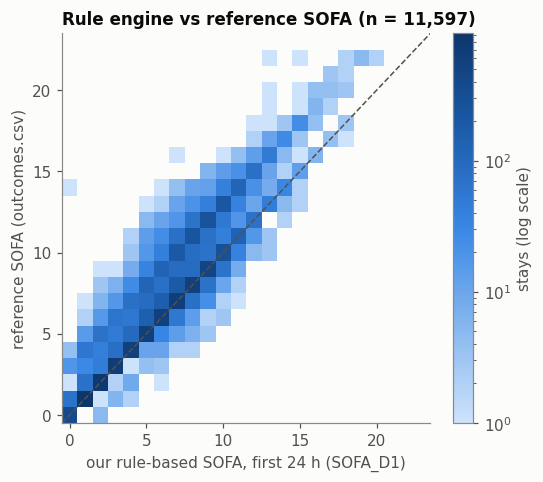

In [8]:
# Where does the mean bias come from? Compare the reference's implied cardiovascular
# sub-score (reference total minus our other five organs) with ours (capped at 0/1).
ours_cardio = m.cardio_d1.fillna(0)
implied_ref_cardio = (m.SOFA - (m.SOFA_D1 - ours_cardio)).mean()
print(f"average cardiovascular sub-score per patient: reference ~ {implied_ref_cardio:.2f}, ours {ours_cardio.mean():.2f}")
print(f"shortfall {ours_cardio.mean() - implied_ref_cardio:+.2f}  vs  mean(SOFA_D1 - reference) "
      f"{(m.SOFA_D1 - m.SOFA).mean():+.2f}  -> the cardiovascular cap explains the bias")

fig, ax = plt.subplots(figsize=(5.4, 4.6))
hi = int(max(m.SOFA_D1.max(), m.SOFA.max())) + 1
edges = np.arange(-0.5, hi + 1.5, 1)
H, _, _ = np.histogram2d(m.SOFA_D1, m.SOFA, bins=[edges, edges])
pcm = ax.pcolormesh(edges, edges, H.T, cmap=SEQ, norm=LogNorm(vmin=1, vmax=H.max()))
ax.plot([-0.5, hi + 0.5], [-0.5, hi + 0.5], color=INK2, lw=1, ls="--")
ax.set(xlabel="our rule-based SOFA, first 24 h (SOFA_D1)", ylabel="reference SOFA (outcomes.csv)",
       title="Rule engine vs reference SOFA (n = %s)" % f"{len(m):,}")
ax.grid(False)
fig.colorbar(pcm, ax=ax, label="stays (log scale)")
savefig(fig, "task1", "A3_rule_sofa_vs_reference")

**Reading A3.** The engine reproduces both worked examples exactly. Against the reference SOFA:

* **The reference is a first-24 h score, not the 48 h worst.** Among the stays whose Day 2 is worse, `SOFA_D1` tracks the reference better than `SOFA_48h_max` does.
* **The gap is one input.** Our score sits about 0.9 points *below* the reference on average. The cardiovascular accounting explains that bias: SOFA's cardiovascular levels 2–4 are defined by vasopressor dose, which this dataset does not contain, so our cardiovascular sub-score is capped at 0/1.
* **It is not a scoring error.** The correlation is high and almost all of the error is one-directional, which is the signature of a missing input.

We therefore use the engine as defined, state the cap as a limitation, and never use `outcomes.csv` as a training signal.

## A4 Forecast targets *(TRIPOD+AI 8)*

For each stay and decision time, `build_targets` scores two windows:

* the **target window** [*T*−18, *T*+6) h → six sub-scores and the total;
* the **now window** [*T*−24, *T*) h → `SOFA_now`.

From these come the deltas (target - now) and `sofa_rise_ge2_tplus6`. The windows overlap for 18 h, so the binary label compares rolling-window scores; it does not isolate acute worsening during the next 6 h. An organ with no target-window measurement keeps a missing target and is excluded from that organ model (D17).

* the *T* = 42 h target window *is* Day 2, so its totals must equal A3's `SOFA_D2`;
* `SOFA_now` at *T* = 24 h *is* `SOFA_D1`, so it must reproduce A3's agreement with the reference.

In [9]:
t0 = time.time()
if t1cfg.TARGETS_CSV.exists() and not REBUILD_PREPROCESSING:
    tg = pd.read_csv(t1cfg.TARGETS_CSV); source = "cache"
else:
    tg = t1targets.build_targets(records); tg.to_csv(t1cfg.TARGETS_CSV, index=False); source = "built"
print(f"targets {tg.shape} ({source}, {time.time() - t0:.1f}s); rows per stay: "
      f"{tg.groupby('RecordID').size().value_counts().to_dict()}")

chk = tg[tg.origin_h == 42].merge(day[["RecordID", "SOFA_D2"]], on="RecordID")
assert (chk.sofa_24h_tplus6.fillna(0) == chk.SOFA_D2).all()
ref = tg[tg.origin_h == 24].merge(oc[["RecordID", "SOFA"]], on="RecordID").query("SOFA != -1")
print(f"T=42 target == Day-2 SOFA for all {len(chk):,} stays;  SOFA_now(T=24) vs reference: "
      f"r = {stats.pearsonr(ref.sofa_now, ref.SOFA)[0]:.3f}, bias = {(ref.sofa_now - ref.SOFA).mean():+.3f}")

tg.groupby("origin_h")[["sofa_24h_tplus6", "sofa_now", "sofa_delta_tplus6", "sofa_rise_ge2_tplus6",
                        "cardio_instability", "target_window_empty"]].mean().round(3)

targets (48000, 28) (cache, 0.1s); rows per stay: {4: 12000}
T=42 target == Day-2 SOFA for all 12,000 stays;  SOFA_now(T=24) vs reference: r = 0.933, bias = -0.862


,sofa_24h_tplus6,sofa_now,sofa_delta_tplus6,sofa_rise_ge2_tplus6,cardio_instability,target_window_empty
origin_h,,,,,,
24,5.275,5.747,-0.483,0.046,0.684,0.002
30,4.982,5.264,-0.294,0.038,0.653,0.002
36,4.81,4.97,-0.172,0.042,0.627,0.002
42,4.631,4.798,-0.179,0.039,0.603,0.003


### How much is there to forecast? Target volatility by organ

Before fitting anything we ask how much each organ's score changes when its 24-hour window advances by 6 h. A model can only beat "nothing changes" where something *does* change, and it needs enough measured rows to learn from.

The table pools all splits and horizons. It describes the outcome variable itself, not a model, so pooling cannot leak anything.

,rows with Δ defined,% of rows measured,% unchanged after a 6-h window shift (Δ = 0),mean |Δ|,std(Δ)
Neurological,47119,98.24,81.262,0.299,0.764
Respiratory,21944,47.346,81.17,0.232,0.571
Renal,47292,98.994,93.439,0.084,0.362
Coagulation,44615,95.01,92.724,0.077,0.294
Cardiovascular,47160,98.292,91.779,0.082,0.286
Liver,19273,41.604,96.965,0.032,0.191


Score-value distribution (target window, measured rows). Cardiovascular can only be 0 or 1:


,% at 0,% at 1,% at 2,% at 3,% at 4
Cardiovascular,26.1,73.9,unreachable,unreachable,unreachable
Renal,64.6,18.9,7.3,4.7,4.4
Neurological,33.2,13.6,14.6,22.7,15.9


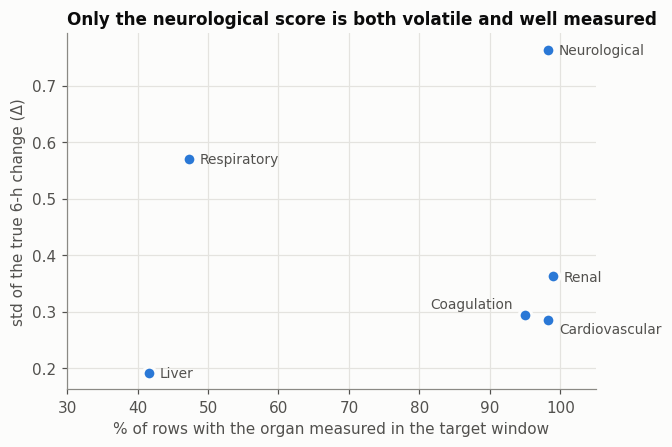

In [10]:
vol = pd.DataFrame({
    AXIS_NAME[a]: {
        "rows with Δ defined": int(tg[f"{a}_delta"].notna().sum()),
        "% of rows measured": 100 * tg[f"{a}_score"].notna().mean(),
        "% unchanged after a 6-h window shift (Δ = 0)": 100 * (tg[f"{a}_delta"].dropna() == 0).mean(),
        "mean |Δ|": tg[f"{a}_delta"].abs().mean(),
        "std(Δ)": tg[f"{a}_delta"].std(),
    } for a in AXES}).T.sort_values("std(Δ)", ascending=False)
display(vol.round(3))

dist = pd.DataFrame({AXIS_NAME[a]: tg[f"{a}_score"].value_counts(normalize=True).reindex(range(5)).mul(100)
                     for a in ("cardio", "renal", "neuro")}).T
dist.columns = [f"% at {k}" for k in range(5)]
print("Score-value distribution (target window, measured rows). Cardiovascular can only be 0 or 1:")
display(dist.round(1).fillna("unreachable"))

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.scatter(vol["% of rows measured"], vol["std(Δ)"], s=70, color=SERIES[0], edgecolor=SURFACE, linewidth=2, zorder=3)
label_pos = {"Coagulation": ((-8, 4), "right"), "Cardiovascular": ((7, -9), "left")}   # avoid overlap
for name, r in vol.iterrows():
    xy, ha = label_pos.get(name, ((7, -3), "left"))
    ax.annotate(name, (r["% of rows measured"], r["std(Δ)"]), xytext=xy, textcoords="offset points",
                ha=ha, color=INK2, fontsize=9)
ax.set(xlabel="% of rows with the organ measured in the target window", ylabel="std of the true 6-h change (Δ)",
       title="Only the neurological score is both volatile and well measured", xlim=(30, 105))
savefig(fig, "task1", "A4_target_volatility")

## A5 Data partitioning *(TRIPOD+AI 12a)*: split before any statistic is computed

The split is at record level, so a stay's four horizon rows never straddle splits. It is 70/15/15 train/validation/test, stratified on SOFA band × in-hospital death, with seed 42, and frozen. The split comes **before** feature construction because some features need statistics, such as the median admission weight, and those must be fitted on training stays only.

Hyperparameters and pre-processing choices are made on **validation**; **test** is scored once, after selection.

In [11]:
sp = t1splits.make_splits()
sp.to_csv(t1cfg.SPLITS_CSV, index=False)
train_ids = set(sp.loc[sp.split == "train", "RecordID"])
print(sp.split.value_counts().to_dict())
t1splits.split_summary(sp, icutype)

{'train': 8400, 'val': 1800, 'test': 1800}


,n,pct,sofa_mean,sofa_p25,sofa_p75,death_rate,sofa_missing,icu1,icu2,icu3,icu4
train,8400,70,6.66,3,9,0.142,282,0.146,0.211,0.358,0.285
val,1800,15,6.66,3,9,0.143,61,0.155,0.21,0.353,0.282
test,1800,15,6.67,3,9,0.142,60,0.148,0.21,0.362,0.28


## A6 Pre-processing and feature engineering

### A6.1 Outlier handling: physiological screening of model inputs

The methodology cleaning in A2 removes only what the SOFA document specifies. Plenty of physiologically impossible values survive it:

* arterial pressures of 0, i.e. a disconnected line;
* temperatures of −17.8 °C, which is 0 °F;
* single urine entries of 20 L, and HR = 0.

Before they reach the **model inputs**, every value is checked against clinical plausibility bounds (`src/shared/physiology.py`, the same bounds task 2 uses). Out-of-range values become **missing rather than clipped**, because clipping would pile artificial values up at the bound. Two unit errors are corrected first: pH without its decimal point, and height in metres. The bounds come from clinical knowledge, not from the data, so the screen cannot leak information.

The **SOFA blocks and the forecast target keep the methodology cleaning unchanged**. The outcome definition is fixed a priori and validated in A3; redefining it after seeing the data would be outcome tampering.

In [12]:
screen = t1features.input_screening_audit(records)
print(f"values set to missing by the physiological screen: {screen['set to missing'].sum():,} "
      f"of {screen['values'].sum():,} in the affected variables")
screen.round(3)

values set to missing by the physiological screen: 7,686 of 4,675,975 in the affected variables


,values,set to missing,%
DiasABP,440026,2011,0.457
SysABP,440215,1986,0.451
MAP,440807,1045,0.237
NIDiasABP,294617,845,0.287
NISysABP,295063,611,0.207
Urine,411163,415,0.101
Temp,259538,311,0.12
RespRate,165435,199,0.12
NIMAP,290381,88,0.03
HR,687134,66,0.01


### A6.2 Feature engineering: expanding-window features at each decision time

For each stay and decision time *T*, `build_features` uses only measurements time-stamped before *T*. It produces 407 predictors in five families:

| Family | Count | What it encodes |
|---|---|---|
| `v_<variable>_<stat>` | 360 | For each of 36 vitals and labs: last, first, min, max, mean, std, count, hours since last value, hours of coverage, 12-h slope. These are level, extremes, variability, trend, and **measurement behaviour** (count, recency). |
| `e_*` | 14 | Clinically engineered: MAP minimum and share of readings < 70 / < 65 mmHg; minimum GCS and suspected sedation (GCS ≤ 8 while ventilated); 24-h urine output (mL/kg/h); minimum PaO₂/FiO₂ |
| `sofa0_24_*` | 14 | Rule-engine organ sub-scores and total for the admission day [0, 24) h |
| `sofa_now_*` | 14 | Rule-engine sub-scores for the last 24 h, the persistence anchor |
| `d_*` | 5 | Age, sex, ICU type, admission weight, height (screened) |

The decision time `origin_h` is a further predictor. Where the urine-rate feature needs a missing admission weight, it uses the **sex-specific median weight of training stays only**, flagged by `e_weight_imputed`.

In [13]:
t0 = time.time()
if t1cfg.FEATURES_CSV.exists() and not REBUILD_PREPROCESSING:
    ft = pd.read_csv(t1cfg.FEATURES_CSV); source = "cache"
else:
    ft = t1features.build_features(records, train_ids); ft.to_csv(t1cfg.FEATURES_CSV, index=False); source = "built"
fam = pd.Series([c.split("_")[0] for c in ft.columns if c not in ("RecordID", "origin_h")]).value_counts()
print(f"features {ft.shape} ({source}, {time.time() - t0:.1f}s); {ft.shape[1] - 2} predictors + origin_h: {fam.to_dict()}")

# leakage / construction checks
ok = True
for v in ["v_HR_count", "v_GCS_count", "v_Urine_count", "v_Creatinine_count"]:
    piv = ft.pivot_table(index="RecordID", columns="origin_h", values=v)
    ok &= bool(((piv[24] <= piv[30]) & (piv[30] <= piv[36]) & (piv[36] <= piv[42])).all())
assert ok, "measurement counts must be non-decreasing in T (expanding window)"
assert (ft.pivot_table(index="RecordID", columns="origin_h", values="sofa0_24_total").nunique(axis=1) == 1).all()
assert not [c for c in ft.columns if c.lower() in ("sofa", "saps-i", "survival", "length_of_stay", "in-hospital_death")]
print("checks passed: expanding-window counts monotone in T; admission-day SOFA identical across T; no outcomes.csv column")

features (48000, 409) (cache, 1.7s); 407 predictors + origin_h: {'v': 360, 'e': 14, 'sofa0': 14, 'sofa': 14, 'd': 5}


checks passed: expanding-window counts monotone in T; admission-day SOFA identical across T; no outcomes.csv column


### A6.3 Missing data *(TRIPOD+AI 11)*

Two mechanisms are handled differently, by design:

* **A predictor never measured before *T*** (for example, no blood gas) stays `NaN`.
  * The tree models (HistGB, LightGBM, CatBoost) route missing values natively at each split, so "never measured" is not turned into "measured normal". The `count` and `hrs_since_last` features also make missingness itself an input: tests are ordered when clinicians are worried.
  * The linear models cannot take NaN. Their pipeline median-imputes (median fitted on training rows) and **adds a 0/1 missing-indicator column** for every feature that had missing values in training, so the model can still use the fact that a value was missing.
* **An outcome organ never measured in the target window** is excluded from that organ's training and evaluation rows (D17). It is never zero-filled, so no model learns that "unmeasured" means "score 0".

In [14]:
nan_frac = ft.drop(columns=["RecordID", "origin_h"]).isna().mean()
by_family = nan_frac.groupby([c.split("_")[0] for c in nan_frac.index]).agg(["count", "median", "max"])
by_family.columns = ["features", "median missing fraction", "max missing fraction"]
print(f"fully populated columns: {(nan_frac == 0).sum()} / {len(nan_frac)};  median missing fraction {nan_frac.median():.2f}")
display(by_family.round(3))
print("most-missing predictors (candidates for the filter in A7):")
nan_frac.sort_values(ascending=False).head(8).round(4).to_frame("missing fraction")

fully populated columns: 60 / 407;  median missing fraction 0.18


,features,median missing fraction,max missing fraction
d,5,0.001,0.48
e,14,0.016,0.412
sofa,14,0,0.598
sofa0,14,0,0.624
v,360,0.267,1


most-missing predictors (candidates for the filter in A7):


,missing fraction
v_Cholesterol_slope12h,1
v_TroponinI_slope12h,0.997
v_Albumin_slope12h,0.9934
v_TroponinT_slope12h,0.9856
v_ALP_slope12h,0.9856
v_ALT_slope12h,0.985
v_AST_slope12h,0.985
v_Bilirubin_slope12h,0.9845


### A6.4 Encoding and scaling

| Model family | Nominal ICU type (codes 1–4) | Scaling |
|---|---|---|
| HistGB, LightGBM, ordinal (trees) | integer code: a tree can isolate any code with ≤ 3 splits | none; trees split on rank order, so scale does not matter |
| CatBoost | **native categorical** (ICU type, sex and decision time as categories, ordered target statistics) | none |
| Linear (Ridge / logistic) | **one-hot encoded**: a code is a category, not a quantity, and a linear model must not treat surgical (4) as "4× coronary" (1) | **standardised** (z-score fitted on training rows), so the L2 penalty treats every coefficient alike |

The cell fits the linear pre-processor on the training rows to show what it produces.

In [15]:
X_demo = ft[ft.RecordID.isin(train_ids)].drop(columns=["RecordID"])
filt_demo = t1m.feature_filter().fit(X_demo)
prep_demo = linear_preprocessor(["d_icutype"]).fit(filt_demo.transform(X_demo))
names = prep_demo.get_feature_names_out()
print(f"{X_demo.shape[1]} input columns -> {len(filt_demo.keep_)} after the filter -> {len(names)} model columns "
      f"({sum(n.startswith('d_icutype_') for n in names)} one-hot ICU-type columns, "
      f"{sum(n.startswith('missingindicator_') for n in names)} missing-indicator columns, rest standardised)")
print("one-hot columns:", [n for n in names if n.startswith("d_icutype_")])

408 input columns -> 358 after the filter -> 667 model columns (4 one-hot ICU-type columns, 306 missing-indicator columns, rest standardised)
one-hot columns: ['d_icutype_1.0', 'd_icutype_2.0', 'd_icutype_3.0', 'd_icutype_4.0']


## A7 Feature selection

Three complementary mechanisms:

1. **Filter selection inside every pipeline** (`FeatureFilter`, `src/shared/preprocessing.py`). Fitted on each model's own training rows, it drops a column that is:
   * **constant** in training;
   * **≥ 99 % missing** in training;
   * a **near-duplicate** (|r| ≥ 0.98) of a more complete column.

   It uses no labels, so it cannot leak outcome information. Protected columns are always kept: the decision time, the nominal descriptors, and each organ's `SOFA_now` anchor. A10 checks that the filter costs no accuracy.
2. **Embedded selection** by the tree models, which choose split features greedily, together with L2 shrinkage in the linear models.
3. **Post-hoc importance** by permutation (A12), which shows what each fitted model actually relies on.

The filter below is fitted on all training rows, pooled across horizons, to show what it removes and why.

In [16]:
rep = filt_demo.report()
print(f"filter fitted on {len(X_demo):,} training rows: keeps {len(filt_demo.keep_)} of {X_demo.shape[1]} columns")
display(rep.rule.value_counts().rename("columns dropped").to_frame())
display(rep.groupby("rule").head(4)[["feature", "reason"]].reset_index(drop=True))

filter fitted on 33,600 training rows: keeps 358 of 408 columns


,columns dropped
rule,
near-duplicate,41
constant,6
mostly missing,3


,feature,reason
0,v_MechVent_last,constant
1,v_MechVent_first,constant
2,v_MechVent_min,constant
3,v_MechVent_max,constant
4,v_Albumin_slope12h,missing >= 99%
5,v_Cholesterol_slope12h,missing >= 99%
6,v_TroponinI_slope12h,missing >= 99%
7,v_SysABP_count,|r| >= 0.98 with v_MAP_count
8,v_NISysABP_count,|r| >= 0.98 with v_NIMAP_count
9,v_DiasABP_count,|r| >= 0.98 with v_MAP_count


## A8 Baselines *(TRIPOD+AI 12e)*

Before any model is fitted, we fix the bar each task must clear (D18):

* **Regression: persistence**, `sofa_24h_tplus6_hat = SOFA_now`. A model that cannot beat it is only relearning "the future looks like the present".
* **Classification: the no-skill reference.** AUROC = 0.5, but AUPRC = **prevalence**, not 0.5 (Saito & Rehmsmeier 2015). With roughly 4 % positives, an AUPRC of 0.2 can sound good while still being weak.

In [17]:
J = ft.merge(tg, on=["RecordID", "origin_h"]).merge(sp[["RecordID", "split"]], on="RecordID")
base = J.dropna(subset=["sofa_24h_tplus6"])
print("rows with a total-SOFA target, per split x horizon:")
display(base.groupby(["split", "origin_h"]).size().unstack())

persist = t1eval.regression_report(base[base.split == "train"], "sofa_24h_tplus6", {"persistence": "sofa_now"})
print("total-SOFA persistence baseline (train):")
display(persist.round(3))

no_skill = pd.DataFrame([{"origin_h": T, **t1eval.no_skill_reference(
    base[(base.split == "train") & (base.origin_h == T)].sofa_rise_ge2_tplus6)} for T in t1cfg.HORIZONS_H])
print("rolling 24-hour proxy-SOFA ≥2-point rise no-skill reference (train):")
display(no_skill.round(4))

rows with a total-SOFA target, per split x horizon:


origin_h,24,30,36,42
split,,,,
test,1797,1797,1796,1797
train,8383,8381,8380,8377
val,1795,1794,1795,1795


total-SOFA persistence baseline (train):


,origin_h,series,n,mae,mae_lo,mae_hi,rmse,rmse_lo,rmse_hi
0,24,persistence,8383,0.934,0.904,0.964,1.663,1.617,1.709
1,30,persistence,8381,0.693,0.669,0.718,1.275,1.235,1.317
2,36,persistence,8380,0.634,0.613,0.656,1.208,1.171,1.245
3,42,persistence,8377,0.599,0.577,0.622,1.232,1.189,1.278


rolling 24-hour proxy-SOFA ≥2-point rise no-skill reference (train):


,origin_h,prevalence,auroc,auprc,brier
0,24,0.0454,0.5,0.0454,0.0434
1,30,0.039,0.5,0.039,0.0375
2,36,0.0406,0.5,0.0406,0.0389
3,42,0.0383,0.5,0.0383,0.0369


## A9 Model development methods and pipelines *(TRIPOD+AI 12b–12g, 13–15)*

We compare **five model families head-to-head** under one protocol, plus one controlled ablation. Each organ gets its own model, and the six predictions are summed into the total.

| Family | What it predicts | Pipeline (every step fitted on training rows) |
|---|---|---|
| **Ordinal** (D19; Frank & Hall 2001) | absolute score via 4 binary classifiers P(score > *k*); E[score] = Σₖ P(score > *k*) | filter → HistGB classifier (per threshold) |
| **Linear** (D20) | Δ from `SOFA_now` (Ridge); logistic regression for the rolling 24-hour proxy-SOFA ≥2-point rise label | filter → [one-hot ICU type, median impute + missing indicators, standardise] → Ridge / logistic |
| **HistGB**, *primary* (D12–D14, D17) | Δ from `SOFA_now`; one model per organ, pooled over horizons | filter → HistGB (native NaN) |
| **CatBoost** (D21) | Δ; native categoricals; ordered boosting | filter → CatBoost |
| **LightGBM** (D22) | Δ; leaf-wise growth | filter → LightGBM (deterministic) |
| *HistGB-absolute* (ablation) | absolute score, otherwise identical to HistGB | filter → HistGB |

**Protocol, identical for every family:**

* Each family has a fixed four-point grid. Every point is fit on train and scored on validation.
* We never use a library's internal early stopping, because it would silently reuse training rows. HistGB's default (`early_stopping="auto"`) switches early stopping *on* above 10,000 rows, so it is set to `False` explicitly.
* Regressors are selected on validation MAE; classifiers on validation AUPRC.
* Δ predictions are reconstructed as `clip(SOFA_now + Δ, 0, 4)`.
* An organ with no `SOFA_now` anchor predicts 0 for every family (D24), so all families are scored on the identical population.

In [18]:
VARIED = ("learning_rate", "max_leaf_nodes", "depth", "num_leaves", "alpha", "C")


def _fmt(v):
    try:
        return f"{float(v):g}"
    except (TypeError, ValueError):
        return str(v)


def cfg_label(params):
    return ", ".join(f"{k}={_fmt(params[k])}" for k in VARIED if k in params)


grids = {"ordinal (per threshold)": t1m.ordinal.GRID, "linear Ridge": t1m.linear.RIDGE_GRID,
         "linear logistic": t1m.linear.LOGISTIC_GRID, "histgb": t1m.REGRESSOR_GRID,
         "catboost": t1m.catboost_model.REGRESSOR_GRID, "lightgbm": t1m.lightgbm_model.REGRESSOR_GRID}
pd.DataFrame({name: [cfg_label(p) for p in g] + [""] * (4 - len(g)) for name, g in grids.items()},
             index=[f"config {i + 1}" for i in range(4)]).T

,config 1,config 2,config 3,config 4
ordinal (per threshold),"learning_rate=0.05, max_leaf_nodes=31","learning_rate=0.05, max_leaf_nodes=63","learning_rate=0.1, max_leaf_nodes=31","learning_rate=0.1, max_leaf_nodes=63"
linear Ridge,alpha=0.1,alpha=1,alpha=10,
linear logistic,C=0.1,C=1,C=10,
histgb,"learning_rate=0.05, max_leaf_nodes=31","learning_rate=0.05, max_leaf_nodes=63","learning_rate=0.1, max_leaf_nodes=31","learning_rate=0.1, max_leaf_nodes=63"
catboost,"learning_rate=0.05, depth=4","learning_rate=0.05, depth=6","learning_rate=0.1, depth=4","learning_rate=0.1, depth=6"
lightgbm,"learning_rate=0.05, num_leaves=31","learning_rate=0.05, num_leaves=63","learning_rate=0.1, num_leaves=31","learning_rate=0.1, num_leaves=63"


## A10 Model training *(TRIPOD+AI 12c)*

With `RETRAIN_TASK1 = True`, each family is fitted here and its fitted pipelines are saved to `trained_models/task1_sofa/<family>/`. Chosen hyperparameters, every grid point's validation score, the class-imbalance experiment and the filter ablation go to `model_spec.json`. With `False`, the saved pipelines are loaded, and any family missing from disk is still trained.

Each table shows the validation score of every grid point per organ. ★ marks the selected configuration.

In [19]:
SPEC_PATH = t1cfg.MODELS_DIR / "model_spec.json"
spec = json.loads(SPEC_PATH.read_text()) if (SPEC_PATH.exists() and not RETRAIN_TASK1) else {}
spec.update({"seed": t1cfg.SEED, "horizons": list(t1cfg.HORIZONS_H),
             "feature_columns": t1m.feature_columns(ft)})
spec.setdefault("families", {})


def _records(grid):
    if isinstance(grid, pd.DataFrame):
        return grid.to_dict("records")
    return {str(k): _records(v) for k, v in grid.items()}


def save_spec():
    SPEC_PATH.write_text(json.dumps(spec, indent=2, default=str))


def save_family(name, axis_models, axis_params, axis_grids, det=None, det_params=None, det_grid=None, **extra):
    d = t1cfg.MODELS_DIR / name
    d.mkdir(parents=True, exist_ok=True)
    for axis, mdl in axis_models.items():
        joblib.dump(mdl, d / f"axis_{axis}.joblib")
    entry = {"axis_params": axis_params, "validation_grids": _records(axis_grids), **extra}
    if det is not None:
        joblib.dump(det, d / "sofa_rise_ge2_tplus6.joblib")
        entry.update(sofa_rise_params=det_params, sofa_rise_grid=_records(det_grid))
    spec["families"][name] = entry
    FITTED_NOW.add(name)
    save_spec()


def load_family(name):
    d = t1cfg.MODELS_DIR / name
    axis_models = {a: joblib.load(d / f"axis_{a}.joblib") for a in AXES}
    det = joblib.load(d / "sofa_rise_ge2_tplus6.joblib") if (d / "sofa_rise_ge2_tplus6.joblib").exists() else None
    return axis_models, det


def needs_training(name):
    return RETRAIN_TASK1 or not (t1cfg.MODELS_DIR / name / "axis_resp.joblib").exists()


def grid_table(grids, metric, best="min"):
    """rows = organ, columns = grid configuration, values = validation metric; ★ = selected."""
    out = {}
    for axis, g in grids.items():
        g = pd.DataFrame(g)
        vals = dict(zip(g.apply(cfg_label, axis=1), g[metric]))
        finite = {k: v for k, v in vals.items() if pd.notna(v)}
        pick = (min(finite, key=finite.get) if best == "min" else max(finite, key=finite.get)) if finite else None
        out[AXIS_NAME.get(axis, axis)] = {k: (f"{v:.4f}{' ★' if k == pick else ''}" if pd.notna(v) else "n/a (one class)")
                                          for k, v in vals.items()}
    return pd.DataFrame(out).T


def show_family(name, metric="val_mae", best="min"):
    entry = spec["families"].get(name, {})
    if "validation_grids" in entry:
        display(grid_table(entry["validation_grids"], metric, best))


train_times, FITTED_NOW = {}, set()


def fit_status(name):
    if name in FITTED_NOW:
        return f"fitted in {train_times[name] / 60:.1f} min"
    return f"loaded the pipelines this cell fitted earlier, from trained_models/task1_sofa/{name}/"

### A10.1 Ordinal (D19)

In [20]:
t0 = time.time()
if needs_training("ordinal"):
    ordinal_models, ordinal_params, ordinal_grids = t1m.ordinal.train_axis_models_ordinal(ft, tg, sp)
    save_family("ordinal", ordinal_models, ordinal_params, ordinal_grids)
else:
    ordinal_models, _ = load_family("ordinal")
train_times["ordinal"] = time.time() - t0
print(f"ordinal: 6 organs x 4 thresholds ({fit_status('ordinal')}). Validation AUROC per threshold classifier:")
og = spec["families"]["ordinal"]["validation_grids"]
display(pd.concat({AXIS_NAME[a]: grid_table({f"P(score>{k})": g for k, g in og[a].items()}, "val_auroc", "max")
                   for a in AXES}))

ordinal: 6 organs x 4 thresholds (loaded the pipelines this cell fitted earlier, from trained_models/task1_sofa/ordinal/). Validation AUROC per threshold classifier:


learning_rate=0.05, max_leaf_nodes=31 learning_rate=0.05, max_leaf_nodes=63 learning_rate=0.1, max_leaf_nodes=31 learning_rate=0.1, max_leaf_nodes=63
Respiratory    P(score>0)                                0.9722                              0.9728 ★                               0.9718                               0.9721
               P(score>1)                              0.9781 ★                                0.9779                               0.9775                               0.9772
               P(score>2)                                0.9640                              0.9654 ★                               0.9633                               0.9643
               P(score>3)                              0.9611 ★                                0.9574                               0.9522                               0.9571
Coagulation    P(score>0)                                0.9932                              0.9936 ★                               0.9932                               0.9934
               P(score>1)                                0.9937                              0.9939 ★                               0.9937                               0.9934
               P(score>2)                                0.9964                                0.9969                             0.9971 ★                               0.9967
               P(score>3)                                0.9981                              0.9983 ★                               0.5396                               0.5808
Liver          P(score>0)                                0.9958                              0.9959 ★                               0.9949                               0.9954
               P(score>1)                                0.9944                              0.9954 ★                               0.9938                               0.9939
               P(score>2)                                0.9961                              0.9967 ★                               0.9956                               0.9956
               P(score>3)                                0.9980                                0.9975                               0.9979                             0.9980 ★
Cardiovascular P(score>0)                                0.9621                              0.9637 ★                               0.9619                               0.9623
               P(score>1)                       n/a (one class)                       n/a (one class)                      n/a (one class)                      n/a (one class)
               P(score>2)                       n/a (one class)                       n/a (one class)                      n/a (one class)                      n/a (one class)
               P(score>3)                       n/a (one class)                       n/a (one class)                      n/a (one class)                      n/a (one class)
Neurological   P(score>0)                                0.9866                                0.9866                               0.9859                             0.9868 ★
               P(score>1)                                0.9961                              0.9961 ★                               0.9957                               0.9961
               P(score>2)                              0.9915 ★                                0.9914                               0.9911                               0.9912
               P(score>3)                                0.9856                                0.9860                               0.9846                             0.9862 ★
Renal          P(score>0)                                0.9947                              0.9950 ★                               0.9949                               0.9949
               P(score>1)                              0.9957 ★                                0.9953                               0.9949                

### A10.2 Linear baseline (D20)

In [21]:
t0 = time.time()
if needs_training("linear"):
    linear_models, linear_params, linear_grids = t1m.linear.train_axis_models_linear(ft, tg, sp)
    det_linear, det_params_linear, det_grid_linear = t1m.linear.train_sofa_rise_model_linear(ft, tg, sp)
    save_family("linear", linear_models, linear_params, linear_grids, det_linear, det_params_linear, det_grid_linear)
else:
    linear_models, det_linear = load_family("linear")
train_times["linear"] = time.time() - t0
print(f"linear ({fit_status('linear')}). Ridge, validation MAE of the delta:")
show_family("linear")
print("rolling 24-hour proxy-SOFA ≥2-point rise (logistic), validation AUPRC:")
display(grid_table({"sofa_rise_ge2_tplus6": spec["families"]["linear"]["sofa_rise_grid"]}, "val_auprc", "max"))

linear (loaded the pipelines this cell fitted earlier, from trained_models/task1_sofa/linear/). Ridge, validation MAE of the delta:


,alpha=0.1,alpha=1,alpha=10
Respiratory,0.3428,0.3426,0.3410 ★
Coagulation,0.1443,0.1443,0.1440 ★
Liver,0.0698,0.0697,0.0692 ★
Cardiovascular,0.1575,0.1575,0.1574 ★
Neurological,0.3735,0.3734,0.3731 ★
Renal,0.1495,0.1495,0.1491 ★


rolling 24-hour proxy-SOFA ≥2-point rise (logistic), validation AUPRC:


,C=0.1,C=1,C=10
sofa_rise_ge2_tplus6,0.1809 ★,0.1744,0.1694


### A10.3 HistGB, the primary family (D12–D14, D17), and the class-imbalance strategy

The rolling 24-hour proxy-SOFA ≥2-point rise label is rare: about 4 % of checkpoints. Before fixing the primary rolling 24-hour proxy-SOFA ≥2-point rise classifier, we compare four ways of handling the imbalance, each over HistGB's full grid and scored on **validation**:

| Strategy | What it does |
|---|---|
| none | plain fit |
| class weights | errors on the rare class weighted up (`class_weight="balanced"`) |
| SMOTE | median-impute, then synthesise minority rows between nearest neighbours |
| random under-sampling | discard majority rows until the classes balance |

The resampling step sits *inside* the pipeline, so it only ever touches training rows; validation and test are never resampled.

**Decision rule.** We keep the **simplest strategy whose validation AUPRC is within one bootstrap standard deviation of the best**. The bootstrap uses 200 resamples of the validation rows, and the order of simplicity is none < class weights < under-sampling < SMOTE. A more complex strategy has to earn its place by more than noise. Brier score is reported alongside, because resampling and re-weighting both distort predicted probabilities.

In [22]:
t0 = time.time()
if needs_training("histgb"):
    histgb_models, histgb_params, histgb_grids = t1m.train_axis_models(ft, tg, sp)
    dfd, dcols = t1m.sofa_rise_frame(ft, tg, sp)
    dva = dfd[dfd.split == "val"]
    yv = dva.sofa_rise_ge2_tplus6.to_numpy().astype(int)
    boot = np.random.default_rng(SEED).integers(0, len(yv), (200, len(yv)))
    imb_rows, imb_fits = {}, {}
    for strategy in t1m.IMBALANCE_STRATEGIES:
        mdl, prm, grd = t1m.train_sofa_rise_model(ft, tg, sp, imbalance=strategy)
        p = mdl.predict_proba(dva[dcols])[:, 1]
        imb_rows[strategy] = {"validation AUROC": roc_auc_score(yv, p),
                              "validation AUPRC": average_precision_score(yv, p),
                              "AUPRC bootstrap SD": float(np.std([average_precision_score(yv[i], p[i]) for i in boot])),
                              "validation Brier": brier_score_loss(yv, p),
                              "chosen config": cfg_label(prm)}
        imb_fits[strategy] = (mdl, prm, grd)
    best_s = max(imb_rows, key=lambda s: imb_rows[s]["validation AUPRC"])
    floor = imb_rows[best_s]["validation AUPRC"] - imb_rows[best_s]["AUPRC bootstrap SD"]
    IMB_T1 = next(s for s in ["none", "class_weight", "undersample", "smote"] if imb_rows[s]["validation AUPRC"] >= floor)
    det_histgb, det_params_histgb, det_grid_histgb = imb_fits[IMB_T1]
    save_family("histgb", histgb_models, histgb_params, histgb_grids, det_histgb, det_params_histgb, det_grid_histgb,
                imbalance_experiment=imb_rows, imbalance_strategy=IMB_T1)
else:
    histgb_models, det_histgb = load_family("histgb")
train_times["histgb"] = time.time() - t0
print(f"histgb ({fit_status('histgb')}). Validation MAE of the delta:")
show_family("histgb")
print("class-imbalance strategies for the rolling 24-hour proxy-SOFA ≥2-point rise classifier (validation):")
display(pd.DataFrame(spec["families"]["histgb"]["imbalance_experiment"]).T.round(4))
IMB_T1 = spec["families"]["histgb"]["imbalance_strategy"]
print(f"-> kept: {IMB_T1}")

histgb (loaded the pipelines this cell fitted earlier, from trained_models/task1_sofa/histgb/). Validation MAE of the delta:


,"learning_rate=0.05, max_leaf_nodes=31","learning_rate=0.05, max_leaf_nodes=63","learning_rate=0.1, max_leaf_nodes=31","learning_rate=0.1, max_leaf_nodes=63"
Respiratory,0.2753 ★,0.2800,0.2882,0.2922
Coagulation,0.0903 ★,0.0924,0.0958,0.0994
Liver,0.0572 ★,0.0607,0.0633,0.0643
Cardiovascular,0.1268 ★,0.1279,0.1321,0.1354
Neurological,0.2375 ★,0.2391,0.2457,0.2476
Renal,0.1061 ★,0.1076,0.1135,0.1159


class-imbalance strategies for the rolling 24-hour proxy-SOFA ≥2-point rise classifier (validation):


,validation AUROC,validation AUPRC,AUPRC bootstrap SD,validation Brier,chosen config
none,0.8172,0.2879,0.029,0.033,"learning_rate=0.05, max_leaf_nodes=63"
class_weight,0.8153,0.2657,0.0279,0.056,"learning_rate=0.05, max_leaf_nodes=31"
smote,0.8311,0.2849,0.0291,0.0324,"learning_rate=0.05, max_leaf_nodes=63"
undersample,0.8133,0.2499,0.027,0.1921,"learning_rate=0.05, max_leaf_nodes=63"


-> kept: none


### A10.4 CatBoost (D21) and LightGBM (D22)

In [23]:
t0 = time.time()
if needs_training("catboost"):
    catboost_models, catboost_params, catboost_grids = t1m.catboost_model.train_axis_models_catboost(ft, tg, sp)
    det_catboost, det_params_cb, det_grid_cb = t1m.catboost_model.train_sofa_rise_model_catboost(ft, tg, sp)
    save_family("catboost", catboost_models, catboost_params, catboost_grids, det_catboost, det_params_cb, det_grid_cb)
else:
    catboost_models, det_catboost = load_family("catboost")
train_times["catboost"] = time.time() - t0
print(f"catboost ({fit_status('catboost')}). Validation MAE of the delta:")
show_family("catboost")

t0 = time.time()
if needs_training("lightgbm"):
    lightgbm_models, lightgbm_params, lightgbm_grids = t1m.lightgbm_model.train_axis_models_lightgbm(ft, tg, sp)
    det_lightgbm, det_params_lgb, det_grid_lgb = t1m.lightgbm_model.train_sofa_rise_model_lightgbm(ft, tg, sp)
    save_family("lightgbm", lightgbm_models, lightgbm_params, lightgbm_grids, det_lightgbm, det_params_lgb, det_grid_lgb)
else:
    lightgbm_models, det_lightgbm = load_family("lightgbm")
train_times["lightgbm"] = time.time() - t0
print(f"lightgbm ({fit_status('lightgbm')}). Validation MAE of the delta:")
show_family("lightgbm")

catboost (loaded the pipelines this cell fitted earlier, from trained_models/task1_sofa/catboost/). Validation MAE of the delta:


,"learning_rate=0.05, depth=4","learning_rate=0.05, depth=6","learning_rate=0.1, depth=4","learning_rate=0.1, depth=6"
Respiratory,0.2810,0.2771 ★,0.2817,0.2813
Coagulation,0.0952,0.0927 ★,0.0963,0.0952
Liver,0.0458 ★,0.0466,0.0495,0.0504
Cardiovascular,0.1293,0.1283 ★,0.1308,0.1304
Neurological,0.2559,0.2499 ★,0.2541,0.2500
Renal,0.1086,0.1080 ★,0.1119,0.1109


lightgbm (loaded the pipelines this cell fitted earlier, from trained_models/task1_sofa/lightgbm/). Validation MAE of the delta:


,"learning_rate=0.05, num_leaves=31","learning_rate=0.05, num_leaves=63","learning_rate=0.1, num_leaves=31","learning_rate=0.1, num_leaves=63"
Respiratory,0.2765 ★,0.2807,0.2856,0.2915
Coagulation,0.0906 ★,0.0922,0.0948,0.0993
Liver,0.0565 ★,0.0602,0.0632,0.0659
Cardiovascular,0.1257 ★,0.1274,0.1320,0.1349
Neurological,0.2366 ★,0.2396,0.2461,0.2493
Renal,0.1048 ★,0.1072,0.1125,0.1142


### A10.5 Ablation: HistGB predicting the absolute score

Ordinal differs from HistGB in **two** ways at once: it predicts the absolute score rather than the Δ, *and* it uses the cumulative-binary decomposition. This control keeps HistGB's learner, grid and pipeline and changes only the target column (`{organ}_score` instead of `{organ}_delta`).

In [24]:
t0 = time.time()
if needs_training("histgb_absolute"):
    absolute_models, absolute_params, absolute_grids = t1m.histgb_absolute.train_axis_models_absolute(ft, tg, sp)
    save_family("histgb_absolute", absolute_models, absolute_params, absolute_grids)
else:
    absolute_models, _ = load_family("histgb_absolute")
train_times["histgb_absolute"] = time.time() - t0
print(f"histgb_absolute ({fit_status('histgb_absolute')}). Validation MAE of the absolute score:")
show_family("histgb_absolute")
if FITTED_NOW:
    print("fitted in this execution (min):", {k: round(train_times[k] / 60, 1) for k in FITTED_NOW})

histgb_absolute (loaded the pipelines this cell fitted earlier, from trained_models/task1_sofa/histgb_absolute/). Validation MAE of the absolute score:


,"learning_rate=0.05, max_leaf_nodes=31","learning_rate=0.05, max_leaf_nodes=63","learning_rate=0.1, max_leaf_nodes=31","learning_rate=0.1, max_leaf_nodes=63"
Respiratory,0.2987 ★,0.3008,0.3118,0.3102
Coagulation,0.1004 ★,0.1006,0.1064,0.1062
Liver,0.0772 ★,0.0802,0.0838,0.0870
Cardiovascular,0.1272 ★,0.1287,0.1333,0.1351
Neurological,0.2491,0.2464 ★,0.2542,0.2558
Renal,0.1138,0.1118 ★,0.1198,0.1213


### A10.6 Does the feature filter cost accuracy?

For the primary family, each organ's chosen configuration is refitted **without** the filter step and compared on validation MAE. The table also shows how many columns each fitted pipeline's filter kept.

In [25]:
from sklearn.ensemble import HistGradientBoostingRegressor
if RETRAIN_TASK1 or "filter_ablation" not in spec:
    abl_rows = {}
    for a in AXES:
        _, X_tr_a, y_tr_a = t1m.axis_frame(ft, tg, sp, a, "train", f"{a}_delta")
        _, X_va_a, y_va_a = t1m.axis_frame(ft, tg, sp, a, "val", f"{a}_delta")
        pipe = histgb_models[a]
        no_filter = HistGradientBoostingRegressor(**pipe.named_steps["model"].get_params()).fit(X_tr_a, y_tr_a)
        abl_rows[AXIS_NAME[a]] = {
            "columns in": X_tr_a.shape[1], "columns kept by filter": len(pipe.named_steps["filter"].keep_),
            "val MAE with filter": t1eval._mae(y_va_a, pipe.predict(X_va_a)),
            "val MAE without filter": t1eval._mae(y_va_a, no_filter.predict(X_va_a))}
    spec["filter_ablation"] = abl_rows
    save_spec()
fa = pd.DataFrame(spec["filter_ablation"]).T
fa["Δ MAE (with − without)"] = fa["val MAE with filter"] - fa["val MAE without filter"]
display(fa.round(4))

kept = {fam: {AXIS_NAME[a]: len((mods[a][0] if fam == "ordinal" else mods[a]).named_steps["filter"].keep_) for a in AXES}
        for fam, mods in (("ordinal", ordinal_models), ("linear", linear_models), ("histgb", histgb_models),
                          ("catboost", catboost_models), ("lightgbm", lightgbm_models))}
print("columns kept by the filter of each fitted pipeline (ordinal: the P(score>0) classifier):")
pd.DataFrame(kept)

,columns in,columns kept by filter,val MAE with filter,val MAE without filter,Δ MAE (with − without)
Respiratory,408,360,0.2753,0.2765,-0.0012
Coagulation,408,356,0.0903,0.0906,-0.0003
Liver,408,360,0.0572,0.057,0.0002
Cardiovascular,408,357,0.1268,0.126,0.0008
Neurological,408,357,0.2375,0.2379,-0.0005
Renal,408,357,0.1061,0.1054,0.0007


columns kept by the filter of each fitted pipeline (ordinal: the P(score>0) classifier):


,ordinal,linear,histgb,catboost,lightgbm
Respiratory,362,360,360,360,360
Coagulation,357,356,356,356,356
Liver,360,360,360,360,360
Cardiovascular,358,357,357,357,357
Neurological,358,357,357,357,357
Renal,358,357,357,357,357


## A11 Results *(TRIPOD+AI 20–23)*

Every family is predicted on all 48,000 rows and joined with the targets. We report validation, used for selection, and **test**, opened once, with 1,000-resample bootstrap 95 % CIs. Persistence uses the same 0-fallback for a missing `SOFA_now` that every model uses (D24).

In [26]:
pred_frames = [t1m.ordinal.predict_axis_scores_ordinal(ordinal_models, ft),
               t1m.linear.predict_axis_scores_linear(linear_models, ft),
               t1m.predict_axis_scores(histgb_models, ft),
               t1m.catboost_model.predict_axis_scores_catboost(catboost_models, ft),
               t1m.lightgbm_model.predict_axis_scores_lightgbm(lightgbm_models, ft),
               t1m.histgb_absolute.predict_axis_scores_absolute(absolute_models, ft)]
preds = reduce(lambda a, b: a.merge(b, on=["RecordID", "origin_h"]), pred_frames)
full = (preds.merge(ft, on=["RecordID", "origin_h"])
             .merge(sp[["RecordID", "split"]], on="RecordID")
             .merge(tg, on=["RecordID", "origin_h"]))
for a in AXES:
    full[f"persistence_{a}"] = full[f"sofa_now_{a}"].fillna(0.0)

FAMILIES = ["ordinal", "linear", "histgb", "catboost", "lightgbm"]
TOTAL_COLS = {"persistence": "sofa_now", "ordinal": "sofa_24h_tplus6_pred_ordinal", "linear": "sofa_24h_tplus6_pred_linear",
              "histgb": "sofa_24h_tplus6_pred", "catboost": "sofa_24h_tplus6_pred_catboost",
              "lightgbm": "sofa_24h_tplus6_pred_lightgbm", "histgb_absolute": "sofa_24h_tplus6_pred_abs"}


def axis_cols(a):
    return {"persistence": f"persistence_{a}", "ordinal": f"{a}_pred_ordinal", "linear": f"{a}_pred_linear",
            "histgb": f"{a}_pred", "catboost": f"{a}_pred_catboost", "lightgbm": f"{a}_pred_lightgbm",
            "histgb_absolute": f"{a}_pred_abs"}


total_rep = {s: t1eval.regression_report(full[full.split == s].dropna(subset=["sofa_24h_tplus6"]), "sofa_24h_tplus6", TOTAL_COLS)
             for s in ("val", "test")}
for s, rep_ in total_rep.items():
    rep_.to_csv(RESULTS["task1"] / f"total_sofa_mae_{s}.csv", index=False)


def mae_pivot(rep_, series):
    t = rep_.assign(cell=lambda d: [ci_str(*r) for r in d[["mae", "mae_lo", "mae_hi"]].to_numpy()])
    return t.pivot(index="origin_h", columns="series", values="cell")[series]


headline = ["persistence"] + FAMILIES
print("TOTAL-SOFA MAE [95% CI], validation:")
display(mae_pivot(total_rep["val"], headline))
print("TOTAL-SOFA MAE [95% CI], TEST:")
display(mae_pivot(total_rep["test"], headline))

TOTAL-SOFA MAE [95% CI], validation:


series,persistence,ordinal,linear,histgb,catboost,lightgbm
origin_h,,,,,,
24,"0.897 [0.832, 0.959]","0.571 [0.534, 0.606]","0.755 [0.713, 0.792]","0.619 [0.585, 0.652]","0.633 [0.597, 0.668]","0.621 [0.586, 0.653]"
30,"0.678 [0.624, 0.730]","0.538 [0.504, 0.573]","0.709 [0.674, 0.746]","0.586 [0.554, 0.621]","0.601 [0.567, 0.635]","0.593 [0.560, 0.627]"
36,"0.617 [0.572, 0.661]","0.574 [0.540, 0.605]","0.718 [0.684, 0.754]","0.606 [0.574, 0.638]","0.616 [0.583, 0.650]","0.610 [0.577, 0.642]"
42,"0.608 [0.555, 0.656]","0.495 [0.458, 0.529]","0.678 [0.640, 0.714]","0.546 [0.510, 0.580]","0.550 [0.512, 0.584]","0.548 [0.510, 0.581]"


TOTAL-SOFA MAE [95% CI], TEST:


series,persistence,ordinal,linear,histgb,catboost,lightgbm
origin_h,,,,,,
24,"0.957 [0.890, 1.018]","0.601 [0.560, 0.640]","0.790 [0.745, 0.833]","0.650 [0.611, 0.688]","0.672 [0.631, 0.710]","0.650 [0.612, 0.687]"
30,"0.706 [0.660, 0.753]","0.577 [0.543, 0.609]","0.723 [0.690, 0.757]","0.619 [0.586, 0.651]","0.637 [0.605, 0.669]","0.626 [0.594, 0.659]"
36,"0.645 [0.597, 0.694]","0.583 [0.545, 0.621]","0.713 [0.678, 0.752]","0.610 [0.575, 0.646]","0.618 [0.582, 0.655]","0.616 [0.581, 0.652]"
42,"0.594 [0.542, 0.644]","0.511 [0.469, 0.549]","0.676 [0.637, 0.713]","0.553 [0.515, 0.589]","0.558 [0.519, 0.594]","0.559 [0.520, 0.594]"


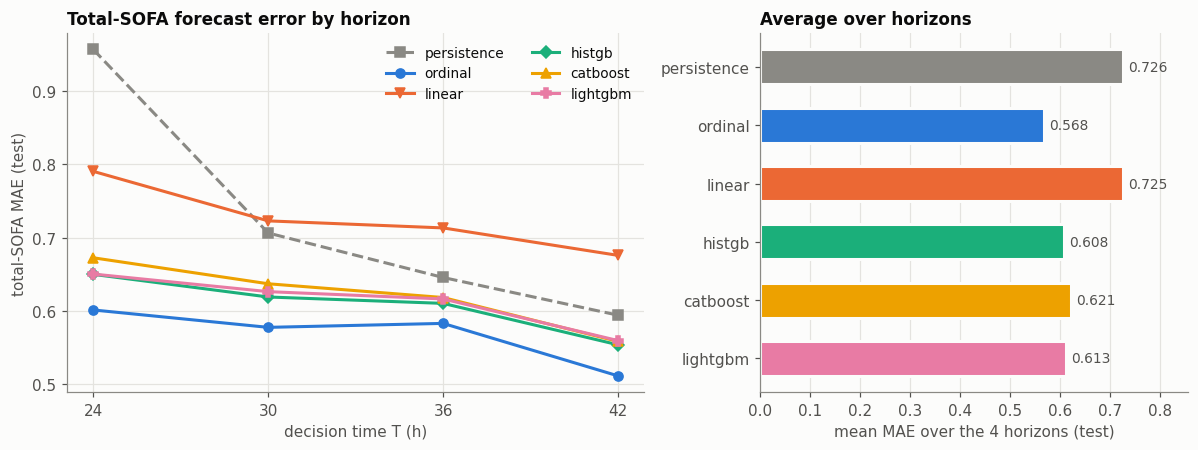

horizons (of 4) where each family beats persistence on test MAE: {'ordinal': 4, 'linear': 1, 'histgb': 4, 'catboost': 4, 'lightgbm': 4}


In [27]:
rep_ = total_rep["test"]
fig, axes_ = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes_[0]
for s in headline:
    d = rep_[rep_.series == s]
    ax.plot(d.origin_h, d.mae, label=s, **FAMILY_STYLE[s])
ax.set(xlabel="decision time T (h)", ylabel="total-SOFA MAE (test)", xticks=list(t1cfg.HORIZONS_H),
       title="Total-SOFA forecast error by horizon")
ax.legend(ncol=2, fontsize=9)

ax = axes_[1]
mean_mae = rep_.groupby("series").mae.mean().reindex(headline)
ypos = np.arange(len(headline))[::-1]
ax.barh(ypos, mean_mae.values, color=[FAMILY_STYLE[s]["color"] for s in headline], height=0.6, edgecolor=SURFACE, linewidth=2)
for y, v in zip(ypos, mean_mae.values):
    ax.text(v + 0.01, y, f"{v:.3f}", va="center", fontsize=9, color=INK2)
ax.set(yticks=ypos, yticklabels=headline, xlabel="mean MAE over the 4 horizons (test)", title="Average over horizons",
       xlim=(0, mean_mae.max() * 1.18))
ax.grid(axis="y", visible=False)
fig.tight_layout()
savefig(fig, "task1", "A11_total_sofa_mae_test")

beats = {s: int((rep_[rep_.series == s].set_index("origin_h").mae <
                 rep_[rep_.series == "persistence"].set_index("origin_h").mae).sum()) for s in FAMILIES}
print("horizons (of 4) where each family beats persistence on test MAE:", beats)

### Per-organ error: where does the gain come from?

Next, MAE per organ, pooled over the four horizons, on test. The heat map shows each family's MAE **relative to persistence**: below 1 (blue) means better than "nothing changes", above 1 (red) means worse.

Per-organ MAE, test, pooled over horizons:


,persistence,ordinal,linear,histgb,catboost,lightgbm,histgb_absolute
Respiratory,0.307,0.307,0.407,0.351,0.353,0.354,0.358
Coagulation,0.082,0.074,0.137,0.099,0.1,0.099,0.104
Liver,0.039,0.037,0.066,0.059,0.051,0.059,0.062
Cardiovascular,0.078,0.104,0.149,0.121,0.123,0.121,0.121
Neurological,0.308,0.2,0.371,0.25,0.264,0.251,0.258
Renal,0.094,0.095,0.151,0.118,0.12,0.117,0.123


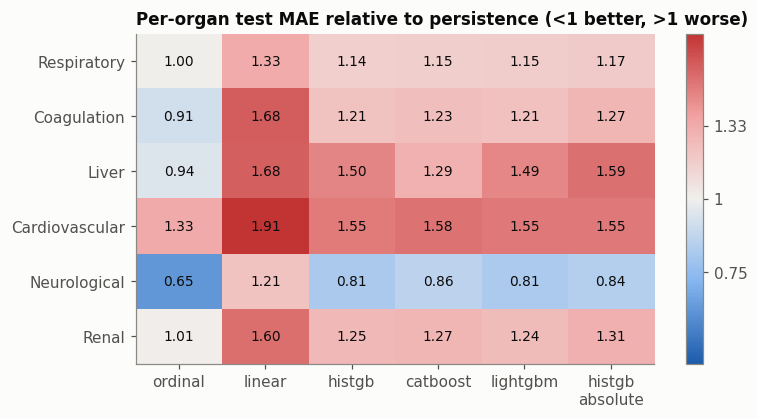

In [28]:
test_rows = full[full.split == "test"]
per_axis = {}
for a in AXES:
    d = test_rows.dropna(subset=[f"{a}_score"])
    per_axis[AXIS_NAME[a]] = {s: t1eval._mae(d[f"{a}_score"], d[c]) for s, c in axis_cols(a).items()}
per_axis = pd.DataFrame(per_axis).T[["persistence"] + FAMILIES + ["histgb_absolute"]]
per_axis.to_csv(RESULTS["task1"] / "per_axis_mae_test.csv")
print("Per-organ MAE, test, pooled over horizons:")
display(per_axis.round(3))

by_h = pd.concat({AXIS_NAME[a]: t1eval.regression_report(test_rows.dropna(subset=[f"{a}_score"]), f"{a}_score", axis_cols(a))
                  for a in AXES}, names=["axis"]).reset_index(level=0)
by_h.to_csv(RESULTS["task1"] / "per_axis_mae_by_horizon_test.csv", index=False)

ratio = per_axis[FAMILIES + ["histgb_absolute"]].div(per_axis["persistence"], axis=0)
fig, ax = plt.subplots(figsize=(7.6, 3.9))
lim = float(np.abs(np.log2(ratio.values)).max())
im = ax.imshow(np.log2(ratio.values), cmap=DIV, vmin=-lim, vmax=lim, aspect="auto")
for i in range(ratio.shape[0]):
    for j in range(ratio.shape[1]):
        ax.text(j, i, f"{ratio.values[i, j]:.2f}", ha="center", va="center", fontsize=9, color=INK)
ax.set(xticks=range(ratio.shape[1]), xticklabels=[c.replace("_", "\n") for c in ratio.columns],
       yticks=range(ratio.shape[0]), yticklabels=ratio.index,
       title="Per-organ test MAE relative to persistence (<1 better, >1 worse)")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, ticks=np.log2([0.5, 0.75, 1, 1.33, 2]))
cb.ax.set_yticklabels(["0.5", "0.75", "1", "1.33", "2"])
savefig(fig, "task1", "A11_per_axis_mae_ratio_test")

### Ablation: absolute target vs ordinal decomposition

If predicting the *absolute* score were what makes ordinal best, HistGB-absolute should close the gap to ordinal. The delta-accuracy table then asks whether the models track real change, rather than just exploiting how rarely SOFA moves. On test, for total SOFA, the predicted Δ is the predicted total minus `SOFA_now`. Directional accuracy is computed over the rows where the true total changes.

In [29]:
abl = total_rep["test"].pivot(index="origin_h", columns="series", values="mae")[
    ["persistence", "histgb", "histgb_absolute", "ordinal"]]
abl.loc["mean"] = abl.mean()
print("Total-SOFA test MAE: HistGB + delta vs HistGB + absolute vs ordinal + absolute")
display(abl.round(3))

d = test_rows.dropna(subset=["sofa_24h_tplus6"])
true_delta = d.sofa_24h_tplus6 - d.sofa_now
moved = true_delta != 0
delta_tbl = {}
for s in ["ordinal", "histgb", "histgb_absolute", "persistence"]:
    pd_ = d[TOTAL_COLS[s]] - d.sofa_now
    delta_tbl[s] = {"n": len(d), "delta MAE": (pd_ - true_delta).abs().mean(),
                    "directional accuracy (rows that change)": (np.sign(pd_[moved]) == np.sign(true_delta[moved])).mean(),
                    "corr(pred Δ, true Δ)": np.corrcoef(pd_, true_delta)[0, 1] if pd_.std() > 0 else np.nan}
print(f"Delta-specific accuracy, total SOFA, test ({int(moved.sum()):,} of {len(d):,} rows change):")
pd.DataFrame(delta_tbl).T.round(3)

Total-SOFA test MAE: HistGB + delta vs HistGB + absolute vs ordinal + absolute


series,persistence,histgb,histgb_absolute,ordinal
origin_h,,,,
24,0.957,0.65,0.658,0.601
30,0.706,0.619,0.63,0.577
36,0.645,0.61,0.625,0.583
42,0.594,0.553,0.563,0.511
mean,0.726,0.608,0.619,0.568


Delta-specific accuracy, total SOFA, test (2,959 of 7,187 rows change):


,n,delta MAE,directional accuracy (rows that change),"corr(pred Δ, true Δ)"
ordinal,7187,0.568,0.839,0.693
histgb,7187,0.608,0.833,0.7
histgb_absolute,7187,0.619,0.827,0.689
persistence,7187,0.726,0,NaN


### Classifying a ≥2-point rise in rolling 24-hour proxy-SOFA

Ordinal has no classifier variant, so four families are compared here. HistGB uses the imbalance strategy chosen in A10.3. The ROC and PR curves are on test; the dashed line is the no-skill reference.

--- val: rolling 24-hour proxy-SOFA ≥2-point rise classifiers (prevalence 0.0386) ---


,series,n,auroc,auroc_lo,auroc_hi,auprc,auprc_lo,auprc_hi,brier
0,histgb,7179,0.817,0.791,0.842,0.288,0.234,0.347,0.033
1,linear,7179,0.783,0.755,0.809,0.181,0.144,0.229,0.17
2,catboost,7179,0.822,0.794,0.846,0.258,0.208,0.312,0.144
3,lightgbm,7179,0.821,0.792,0.846,0.273,0.222,0.329,0.056
0,no-skill,7179,0.5,NaN,NaN,0.039,NaN,NaN,0.037


--- test: rolling 24-hour proxy-SOFA ≥2-point rise classifiers (prevalence 0.0451) ---


,series,n,auroc,auroc_lo,auroc_hi,auprc,auprc_lo,auprc_hi,brier
0,histgb,7187,0.828,0.804,0.85,0.315,0.264,0.366,0.038
1,linear,7187,0.788,0.761,0.813,0.196,0.159,0.239,0.175
2,catboost,7187,0.83,0.808,0.85,0.273,0.224,0.324,0.154
3,lightgbm,7187,0.827,0.805,0.85,0.288,0.238,0.342,0.063
0,no-skill,7187,0.5,NaN,NaN,0.045,NaN,NaN,0.043


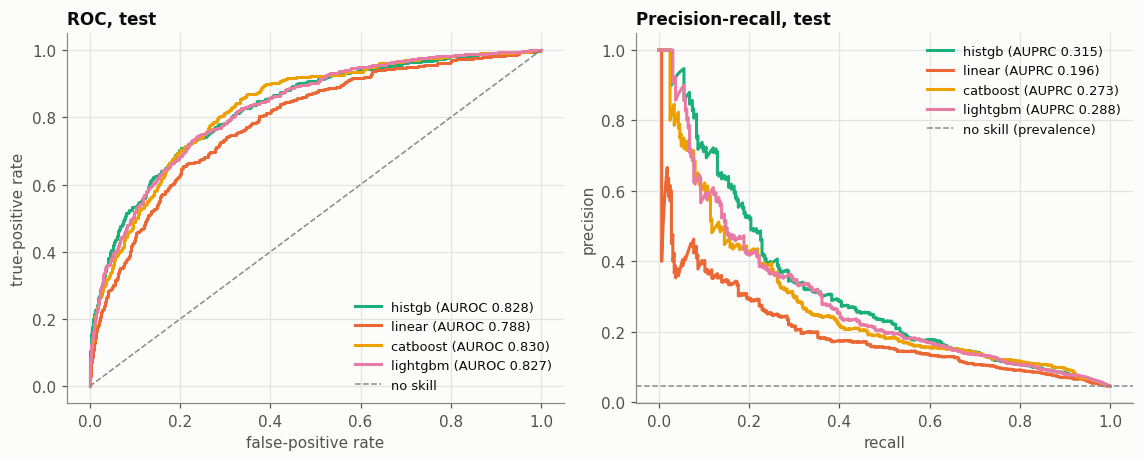

In [30]:
det_frames = [t1m.predict_sofa_rise(det_histgb, ft),
              t1m.linear.predict_sofa_rise_linear(det_linear, ft),
              t1m.catboost_model.predict_sofa_rise_catboost(det_catboost, ft),
              t1m.lightgbm_model.predict_sofa_rise_lightgbm(det_lightgbm, ft)]
det = (reduce(lambda a, b: a.merge(b, on=["RecordID", "origin_h"]), det_frames)
       .merge(sp[["RecordID", "split"]], on="RecordID")
       .merge(tg[["RecordID", "origin_h", "sofa_rise_ge2_tplus6"]], on=["RecordID", "origin_h"]).dropna())
PROB_COLS = {"histgb": "sofa_rise_ge2_proba", "linear": "sofa_rise_ge2_proba_linear",
             "catboost": "sofa_rise_ge2_proba_catboost", "lightgbm": "sofa_rise_ge2_proba_lightgbm"}
det_rep = {}
for s in ("val", "test"):
    dd = det[det.split == s]
    det_rep[s] = t1eval.classification_comparison(dd, "sofa_rise_ge2_tplus6", PROB_COLS)
    ns = t1eval.no_skill_reference(dd.sofa_rise_ge2_tplus6)
    det_rep[s] = pd.concat([det_rep[s], pd.DataFrame([{"series": "no-skill", "n": len(dd), "auroc": 0.5,
                                                         "auprc": ns["auprc"], "brier": ns["brier"]}])])
    det_rep[s].to_csv(RESULTS["task1"] / f"sofa_rise_ge2_{s}.csv", index=False)
    print(f"--- {s}: rolling 24-hour proxy-SOFA ≥2-point rise classifiers (prevalence {ns['prevalence']:.4f}) ---")
    display(det_rep[s].round(3))

dt = det[det.split == "test"]
fig, axes_ = plt.subplots(1, 2, figsize=(10.5, 4.3))
for s, col in PROB_COLS.items():
    st = FAMILY_STYLE[s]
    fpr, tpr, _ = roc_curve(dt.sofa_rise_ge2_tplus6, dt[col])
    prec, rec, _ = precision_recall_curve(dt.sofa_rise_ge2_tplus6, dt[col])
    axes_[0].plot(fpr, tpr, color=st["color"], label=f"{s} (AUROC {roc_auc_score(dt.sofa_rise_ge2_tplus6, dt[col]):.3f})")
    axes_[1].plot(rec, prec, color=st["color"], label=f"{s} (AUPRC {average_precision_score(dt.sofa_rise_ge2_tplus6, dt[col]):.3f})")
axes_[0].plot([0, 1], [0, 1], color=BASELINE, ls="--", lw=1, label="no skill")
axes_[1].axhline(dt.sofa_rise_ge2_tplus6.mean(), color=BASELINE, ls="--", lw=1, label="no skill (prevalence)")
axes_[0].set(xlabel="false-positive rate", ylabel="true-positive rate", title="ROC, test")
axes_[1].set(xlabel="recall", ylabel="precision", title="Precision-recall, test")
for ax in axes_:
    ax.legend(fontsize=8.5)
fig.tight_layout()
savefig(fig, "task1", "A11_sofa_rise_ge2_roc_pr_test")

HistGB rolling 24-hour proxy-SOFA ≥2-point rise classifier, calibration by decile of predicted risk (test):


,bin,n,mean_pred,observed_rate
0,"(-0.0009203, 0.000822]",719,0.001,0.006
1,"(0.000822, 0.00131]",719,0.001,0.006
2,"(0.00131, 0.00187]",718,0.002,0.008
3,"(0.00187, 0.00262]",719,0.002,0.01
4,"(0.00262, 0.00367]",719,0.003,0.014
5,"(0.00367, 0.00531]",718,0.004,0.025
6,"(0.00531, 0.00808]",719,0.007,0.035
7,"(0.00808, 0.014]",718,0.011,0.049
8,"(0.014, 0.0304]",719,0.021,0.07
9,"(0.0304, 0.964]",719,0.116,0.229


Risk stratification: share of positive rolling 24-hour proxy-SOFA ≥2-point rise labels captured by flagging the top-k% of rows (test):


,fraction_flagged,n_flagged,true_positives_captured,capture_rate,capture_rate_lo,capture_rate_hi,lift
0,0.05,359,113,0.349,0.303,0.393,7.736
1,0.1,719,165,0.509,0.456,0.558,11.296
2,0.2,1437,215,0.664,0.611,0.716,14.72


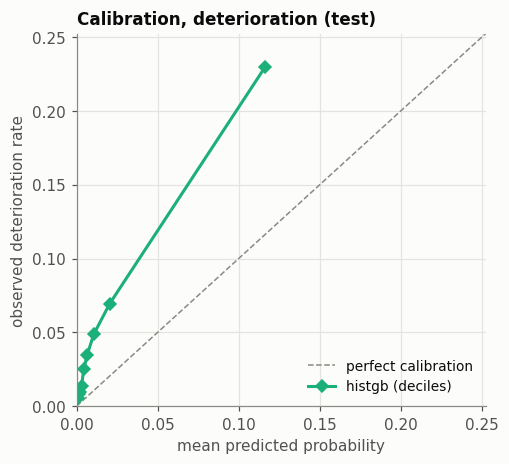

Subgroups, total-SOFA MAE (histgb):


group     n   mae  mae_lo  mae_hi
haemodynamic instability (validation) 0      0  2590 0.598   0.568   0.626
                                      1      1  4483 0.593   0.572   0.615
ICU type (test)                       0      1  1064 0.531   0.484   0.583
                                      1      2  1507 0.743   0.701   0.791
                                      2      3  2600 0.572   0.543   0.599
                                      3      4  2016 0.594   0.568   0.624

In [31]:
cal = t1eval.calibration_table(dt.sofa_rise_ge2_tplus6, dt.sofa_rise_ge2_proba)
print("HistGB rolling 24-hour proxy-SOFA ≥2-point rise classifier, calibration by decile of predicted risk (test):")
display(cal.round(3))

cap = t1eval.capture_rate_report(dt.sofa_rise_ge2_tplus6.to_numpy(), dt.sofa_rise_ge2_proba.to_numpy())
print("Risk stratification: share of positive rolling 24-hour proxy-SOFA ≥2-point rise labels captured by flagging the top-k% of rows (test):")
display(cap.round(3))

fig, ax = plt.subplots(figsize=(4.8, 4.4))
lim_ = float(max(cal.mean_pred.max(), cal.observed_rate.max()) * 1.1)
ax.plot([0, lim_], [0, lim_], color=BASELINE, ls="--", lw=1, label="perfect calibration")
ax.plot(cal.mean_pred, cal.observed_rate, color=FAMILY_STYLE["histgb"]["color"], marker="D", label="histgb (deciles)")
ax.set(xlabel="mean predicted probability", ylabel="observed rolling 24-hour proxy-SOFA ≥2-point rise rate",
       title="Calibration, rolling 24-hour proxy-SOFA ≥2-point rise (test)", xlim=(0, lim_), ylim=(0, lim_))
ax.legend(fontsize=9)
savefig(fig, "task1", "A11_sofa_rise_ge2_calibration_test")

print("Subgroups, total-SOFA MAE (histgb):")
sub = pd.concat({
    "haemodynamic instability (validation)": t1eval.subgroup_report(
        full[full.split == "val"].dropna(subset=["sofa_24h_tplus6"]), "sofa_24h_tplus6", "sofa_24h_tplus6_pred", "cardio_instability"
    ).rename(columns={"cardio_instability": "group"}),
    "ICU type (test)": t1eval.subgroup_report(
        test_rows.dropna(subset=["sofa_24h_tplus6"]).merge(icutype.rename("ICUType"), left_on="RecordID", right_index=True),
        "sofa_24h_tplus6", "sofa_24h_tplus6_pred", "ICUType").rename(columns={"ICUType": "group"}),
})
display(sub.round(3))

## A12 Interpretation: permutation importance (D16)

Permutation importance for the primary family (HistGB), on a fixed 2,000-row validation sample with 3 repeats: how much the validation error grows when one input column is shuffled. Shuffling the raw input columns of the whole pipeline means a column the filter dropped scores exactly 0.

Top-5 features per organ model (increase in validation error when shuffled):


organ,Respiratory,Coagulation,Liver,Cardiovascular,Neurological,Renal
rank,,,,,,
1,sofa_now_resp,v_Platelets_last,sofa_now_liver,sofa_now_cardio,sofa_now_neuro,sofa_now_renal
2,v_PaO2_last,sofa_now_coag,v_Bilirubin_last,e_map_frac_lt70,v_GCS_mean,v_Creatinine_last
3,v_FiO2_last,v_Platelets_hrs_since_last,v_Bilirubin_hrs_since_last,v_MAP_hrs_since_last,v_GCS_last,e_urine_sum_24h
4,v_MechVent_hrs_since_last,v_Platelets_min,v_Mg_hrs_since_last,v_MAP_last,v_GCS_std,v_Creatinine_hrs_since_last
5,v_FiO2_slope12h,v_Temp_count,v_Bilirubin_first,sofa0_24_cardio,v_GCS_first,v_Creatinine_max


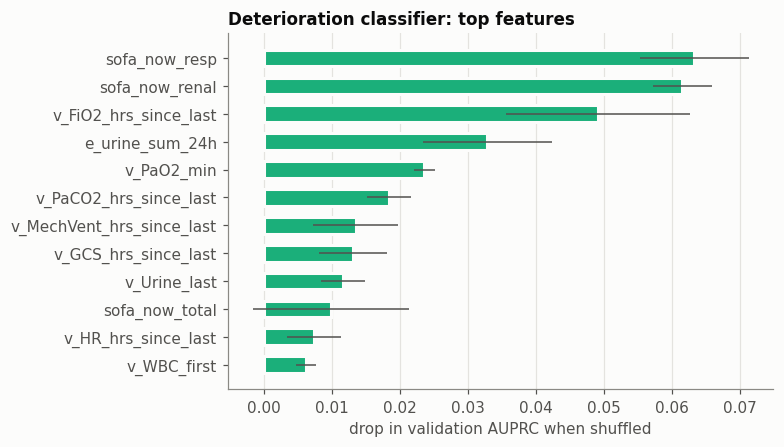

In [32]:
cols = t1m.feature_columns(ft)
val_rows = full[full.split == "val"]
imp_rows = []
for a, mdl in histgb_models.items():
    dd = val_rows.dropna(subset=[f"{a}_delta"])
    imp = t1eval.permutation_report(mdl, dd[cols], dd[f"{a}_delta"], top_k=5)
    imp_rows += [{"organ": AXIS_NAME[a], "rank": i + 1, "feature": r.feature, "importance": r.importance_mean}
                 for i, r in imp.iterrows()]
print("Top-5 features per organ model (increase in validation error when shuffled):")
display(pd.DataFrame(imp_rows).pivot(index="rank", columns="organ", values="feature")[[AXIS_NAME[a] for a in AXES]])

dv = det[det.split == "val"]
Xd = ft.set_index(["RecordID", "origin_h"]).loc[dv.set_index(["RecordID", "origin_h"]).index].reset_index()
imp_det = t1eval.permutation_report(det_histgb, Xd[cols], dv.sofa_rise_ge2_tplus6.to_numpy(),
                                    scoring="average_precision", top_k=12)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ypos = np.arange(len(imp_det))[::-1]
ax.barh(ypos, imp_det.importance_mean, xerr=imp_det.importance_std, color=FAMILY_STYLE["histgb"]["color"],
        height=0.6, edgecolor=SURFACE, linewidth=2, error_kw=dict(ecolor=INK2, lw=1))
ax.set(yticks=ypos, yticklabels=imp_det.feature, xlabel="drop in validation AUPRC when shuffled",
       title="rolling 24-hour proxy-SOFA ≥2-point rise classifier: top features")
ax.grid(axis="y", visible=False)
savefig(fig, "task1", "A12_sofa_rise_ge2_permutation_importance")

## A13 Discussion *(TRIPOD+AI 25–27)*

**Verdict on the four questions this task set out to answer** (test split unless marked):

| Question | Verdict | Evidence |
|---|---|---|
| **H1:** Does ML add information beyond persistence for total SOFA? | **Supported** | Ordinal, HistGB, CatBoost and LightGBM beat persistence at all 4 horizons, on validation and on test. Mean test MAE: ordinal 0.568, HistGB 0.608, persistence 0.726. Ordinal's CIs separate from persistence at *T* = 24 h (0.601 [0.560, 0.640] vs 0.957 [0.890, 1.018]) and at *T* = 30 h (0.577 [0.543, 0.609] vs 0.706 [0.660, 0.753]). By *T* = 36–42 h persistence is already good, and the CIs overlap. |
| **H2:** Is the gain uniform across organs? | **No: concentrated in the neurological organ** | Every non-linear family clearly beats persistence on the neurological score (pooled MAE 0.200–0.264 vs 0.308). Ordinal also edges persistence on coagulation (0.074 vs 0.082) and liver (0.037 vs 0.039), and ties on respiratory (0.307 vs 0.307) and renal (0.095 vs 0.094). Every other family is worse than persistence on those five organs. Cardiovascular is worse than persistence for every family (0.104–0.149 vs 0.078). |
| **H3:** Does formulation matter beyond non-linearity? | **Supported** | The linear baseline loses to persistence at 3 of 4 horizons. HistGB-*absolute* (0.619) is worse than HistGB-*delta* (0.608), yet ordinal, which also predicts the absolute score, is best (0.568). Its edge is the cumulative-binary decomposition, not the absolute target. The models track real change: about 83–84 % directional accuracy on the 2,959 rows whose total moves, and correlation 0.69–0.70 with the true Δ. |
| **H4:** Does the model discriminate a >=2-point difference between rolling proxy-SOFA scores? | **Discrimination yes, calibration no** | AUROC 0.79-0.83 and AUPRC 0.20-0.32, against prevalence 0.045. HistGB AUPRC is 0.315 [0.264, 0.366], about 7x no-skill; its top-risk decile captures 50.9% of positive labels but underestimates that decile observed rate (0.116 vs 0.229). |

**Why the neurological organ?** The volatility analysis (A4) answers this from the outcome itself, before any model is involved. Forecasting helps where the score both *moves* and is *measured*:

* **Neurological:** the only organ with both, std(Δ) 0.76 and 98 % measured.
* **Respiratory:** moves almost as much (0.57) but is measured in only 47 % of rows.
* **Renal, coagulation, cardiovascular:** measured in > 95 % of rows but unchanged in ≥ 92 % of 6-h windows, so little beyond "no change" is available. Ordinal's decomposition still extracts a small gain for coagulation.

Cardiovascular has an extra, data-imposed ceiling: it can only be 0 or 1, because no vasopressor data exist. Permutation importance (A12) agrees from the model side. Each organ model leans on its own current sub-score and latest raw value, while the neurological model also uses several GCS summaries (mean, last, std, first): genuine trajectory information.

**What the pre-processing choices did:**

* **Outlier screening.** The physiological screen removed 7,686 implausible input values, such as arterial pressure 0 and temperature −17.8 °C. These would otherwise feed min/max/slope features.
* **Feature filter.** It drops about 50 of 408 columns: constant `MechVent` summaries, three near-empty slopes, and near-duplicate counts. Validation MAE is unchanged (|Δ| ≤ 0.0012 for every organ), so the models are smaller at no cost.
* **Class imbalance.** No strategy beat plain fitting on AUPRC. SMOTE gave the best AUROC (0.831) but not the best AUPRC (0.285 vs 0.288). Class weights (0.266) and under-sampling (0.250) were worse and inflated the Brier score (0.056 and 0.192 vs 0.033). So the rolling 24-hour proxy-SOFA ≥2-point rise classifier is fitted unweighted.
* **HistGB early stopping.** Making `early_stopping=False` explicit means every HistGB and ordinal model trains on all its training rows, as the protocol requires; sklearn's default would silently hold out 10 % of them.

**Subgroups.** Error does not differ by haemodynamic instability (MAE 0.598 vs 0.593). It is highest in cardiac-surgery recovery (0.743 vs 0.53–0.59 elsewhere), plausibly because these patients are sedated and ventilated after surgery and then wake quickly, so their GCS and respiratory scores swing more within 48 h.

**Limitations.**

1. **No vasopressor data.** The cardiovascular score is capped at 0/1, which also explains the whole 0.86-point mean gap to the reference SOFA (A3).
2. **The target comes from our own rule engine.** It reproduces the methodology document exactly but is not the clinical gold standard.
3. **Internal validation only.** One dataset, and no calendar dates, so drift cannot be assessed.
4. **Probabilities are miscalibrated.** The rolling 24-hour proxy-SOFA ≥2-point rise classifier ranks well but is mis-scaled in either direction: class weights over-state risk and the unweighted fit under-states it. A calibration step fitted on validation (Platt or isotonic) is needed before its outputs are read as probabilities.
5. **A deliberate scoring rule.** Organs without a current-state anchor predict 0 (D24), which keeps families comparable but forgoes predictions from indirect evidence.
6. **Sampled interpretation.** Permutation importance uses a 2,000-row sample, and the ordinal threshold classifiers are not constrained to be monotone.

---
# Part B: Task 2: In-Hospital Mortality Prediction

**Prediction point and inputs:** Use measurements from the first 48 hours after ICU admission to predict in-hospital mortality.

## B1 Problem statement

At the 48-h prediction point, use measurements from [0, 48 h) to predict death before hospital discharge, including after ICU discharge.

* **Inputs.** Observations with 0 ≤ `Time` < 48:00.
* **Cohort.** All 12,000 released stays; retain the 167 records with `Length_of_stay = -1` because length of stay is neither a predictor nor the target. The mortality label is complete: 1,707 deaths (14.2%).
* **48-h eligibility.** The source cohort excludes ICU stays shorter than 48 h, so included stays reach the prediction point.
* **Metrics.** **AUPRC** (primary; the no-skill AUPRC equals the prevalence) and **AUROC**, each with 1,000-resample stratified bootstrap 95 % CIs, plus min(Se, PPV) for comparability with the 2012 challenge.
* **Operating point.** The threshold is chosen on **validation** for recall ≈ 0.80, because a missed death costs more than an extra review.
* **Protocol.** A **ladder** of increasingly complex models: L0 random → L1 one variable → L2 bedside scores (SAPS-I, SOFA) → L3 eight-feature logistic regression → L4 gradient-boosted trees. Each rung must beat the one below to justify its complexity.
* **One test look.** Every pre-processing, imbalance, hyperparameter and feature choice uses train, CV on train, or validation; test is scored once per declared model.

**Where each data-preparation step happens in Part B:**

| Step | What we do | Section |
|---|---|---|
| Data quality audit | Re-derive every output, count sentinels, empty rows, 48:00 rows and duplicates | B2 |
| Cleaning & outliers | `-1` → missing; physiological ranges → missing (not clipped), with unit fixes; same-minute duplicates collapsed | B2 |
| Time-series aggregation | 37 variables × 3 windows × 12 statistics, plus merged blood pressure, BMI and missing indicators | B2, B3 |
| Feature engineering | Clinically derived ratios (P/F, shock index, BUN/Cr, urine mL/kg/h) and rule-based organ sub-scores | B3 |
| Missing data | Trees route NaN natively; logistic regression median-imputes inside its pipeline; static missing indicators | B2, B4 |
| Encoding & scaling | One-hot ICU type and sex; standardisation inside the logistic pipelines; no scaling for trees | B2, B4 |
| Feature selection | Clinical-prior selection (L3); statistic ablation (L3-revised); filter (B4); embedded SHAP top-*k* with nested CV (B6) | B4–B6 |
| Leakage control | Split by stay first; outcome columns excluded from X; every fitted step inside a pipeline | B2, B4 |
| Class imbalance | None / class weights / SMOTE / under-sampling, compared by 5-fold CV on train | B5, B6 |

In [6]:
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

from src.task2_mortality import preprocess as t2pre, verify_outputs as t2verify
from src.task2_mortality import validate_phase3_outputs as t2validate, data as t2data, modeling as t2m
from src.task2_mortality.derived_features import build_derived_features
from src.task2_mortality.metrics import compute_metrics, bootstrap_ci as strat_boot, find_threshold_for_recall, min_se_ppv

T2_PRE = ROOT / "preprocessed" / "task2_mortality"
T2_MODELS = ROOT / "trained_models" / "task2_mortality"
T2_RES = RESULTS["task2"]
T2_MODELS.mkdir(parents=True, exist_ok=True)


def _gpu_ok():
    try:
        xgb.XGBClassifier(device="cuda", n_estimators=1).fit(np.random.RandomState(SEED).rand(50, 3), np.arange(50) % 2)
        return True
    except Exception:
        return False


DEVICE = "cuda" if _gpu_ok() else "cpu"
print("XGBoost device for model development:", DEVICE)

XGBoost device for model development: cuda


C:\Users\SPECTA~1\AppData\Local\Temp\md6117_task2_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:07:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\SPECTA~1\AppData\Local\Temp\md6117_task2_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:07:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


## B2 Pre-processing: raw records → one row per stay *(TRIPOD+AI 7, 9, 11)*

`src/task2_mortality/preprocess.py` turns each stay into a single row. Its rules live in `config.json`:

* **Time window.** Rows timed exactly **48:00** contradict the dataset's 47:59 upper bound. They are excluded from the primary features and exported to a separate sensitivity file.
* **Cleaning and outliers.** `-1` means missing. Values outside clinical **physiological ranges** (`src/shared/physiology.py`, shared with task 1) are set to missing, not clipped. Two unit errors are corrected first: pH > 14 is ÷100, and Height < 100 cm is ×100.
  * *v2 fix:* the age range now starts at 15, as the dataset documentation states. Version 1 blanked the 19 stays aged 15–17.
* **Duplicates.** Values recorded in the same minute are collapsed: continuous values by median, MechVent by max, urine by sum. Every exact duplicate and conflict is audited.
* **Aggregation.** For each of 37 dynamic variables, three windows (0–24 h, 24–48 h, 0–48 h) × 12 statistics: measured, count, first, last, min, max, mean, median, std, slope per hour, delta and time span, plus urine total.
* **Merged and static features.** Merged invasive/non-invasive blood-pressure streams, an arterial-line flag, and static descriptors: age, height, weight, BMI, with missing indicators. **ICU type and sex are one-hot encoded.** Record-level counters are added too.
* **Leakage guard.** SAPS-I, SOFA, length of stay and survival are excluded from X. SAPS-I and SOFA are exported separately, as *scores* for rung L2 only, with `-1` turned into NaN plus an availability flag.
* **Split.** A frozen stratified 70/15/15 split (seed 20260907), assigned before any modelling statistic is computed.

The independent verifiers below re-derive and check every output.

In [7]:
if (REBUILD_PREPROCESSING or not (T2_PRE / "patient_features_unimputed.csv.gz").exists()
        or len(pd.read_csv(T2_PRE / "labels_and_splits.csv")) != 12000):
    t2pre.main()          # ~10 min; rewrites preprocessed/task2_mortality/
summary = json.loads((T2_PRE / "preprocessing_summary.json").read_text(encoding="utf-8"))

verification = t2verify.main()                 # raises AssertionError on any failed check
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    n_checks = t2validate.main()               # raises RuntimeError if any check fails
print(f"independent verification: {verification['status']} ({verification['verified_output_hashes']} output hashes, "
      f"{verification['verified_imputed_cells']:,} imputed cells re-derived); phase-3 validation: {n_checks}/{n_checks} checks passed")

a = summary["audits"]
audit2 = pd.Series({
    "raw rows read": f"{a['raw_rows']:,}",
    "stays in cohort / deaths": f"{summary['source']['record_files']:,} / {summary['source']['death_count']:,} "
                           f"({100 * summary['source']['death_prevalence']:.2f} %)",
    "missing-sentinel or out-of-range values": f"{a['sentinel_rows']:,}",
    "rows with empty Parameter": f"{a['empty_parameter_rows']:,}",
    "rows exactly at 48:00 (sensitivity file only)": f"{a['exact_48h_rows']:,} in {summary['output']['boundary_sensitivity_rows']} stays",
    "same-minute conflicting (time, parameter) keys": f"{a['conflicting_time_parameter_keys']:,}",
    "base model features": summary["output"]["model_feature_columns"],
    "unimputed missing cells": f"{summary['output']['unimputed_missing_cells']:,}",
}, name="value").to_frame()
display(audit2)
display(pd.DataFrame(summary["split_summary"]).round(4))

independent verification: PASS (12 output hashes, 17,688,000 imputed cells re-derived); phase-3 validation: 66/66 checks passed


,value
raw rows read,"5,285,818"
stays in cohort / deaths,"12,000 / 1,707 (14.22 %)"
missing-sentinel or out-of-range values,"15,235"
rows with empty Parameter,"2,403"
rows exactly at 48:00 (sensitivity file only),"1,407 in 234 stays"
"same-minute conflicting (time, parameter) keys","11,337"
base model features,1474
unimputed missing cells,"4,562,193"


,split,rows,deaths,survivors,death_prevalence
0,train,8400,1195,7205,0.1423
1,validation,1800,256,1544,0.1422
2,test,1800,256,1544,0.1422


## B3 Feature engineering

### B3.1 Clinically derived features (v2)

The B2 summaries treat each variable on its own. Several of the strongest bedside signals are **combinations** of variables, which a tree can only approximate with many splits. So they are built explicitly (`src/task2_mortality/derived_features.py`), per window, from screened values:

| Feature | Definition | Clinical meaning |
|---|---|---|
| `pf_ratio` (min, mean, last) | PaO₂ / FiO₂, each PaO₂ paired with the nearest FiO₂ within ±2 h | oxygenation, as used in the Berlin ARDS definition and the SOFA respiratory score |
| `shock_index` (max, mean, last) | HR / systolic BP at the same minute (invasive preferred) | haemodynamic instability; > 1 suggests shock |
| `bun_cr_ratio` (max, last) | BUN / creatinine at the same draw | pre-renal vs intrinsic kidney injury |
| `urine_ml_kg_h` | window urine total / admission weight / hours | the KDIGO oliguria unit (< 0.5 mL/kg/h) |
| `organ_score__{day}__{organ}` | our rule-based SOFA sub-scores for day 1 and day 2, their totals, and the day-2 minus day-1 change | multi-organ dysfunction and its direction |

The proxy-organ scores come from the task 1 rule engine run on the ICU records. They never come from `outcomes.csv`, whose SOFA stays excluded from X.

In [8]:
DERIVED_CSV = T2_PRE / "derived_features.csv.gz"
ids_all = pd.read_csv(T2_PRE / "labels_and_splits.csv").RecordID
if REBUILD_PREPROCESSING or not DERIVED_CSV.exists() or len(pd.read_csv(DERIVED_CSV)) != len(ids_all):
    build_derived_features(ids_all, records).to_csv(DERIVED_CSV, index=False)   # `records`: task 1's cleaned parse

labels, _, _ = t2data.load_data()
X_model = t2data.load_model_matrix(include_derived=True)
FEATS = [c for c in X_model.columns if c != "RecordID"]
DERIVED = [c for c in pd.read_csv(DERIVED_CSV, nrows=1).columns if c != "RecordID"]
lab = labels.set_index("RecordID")
Xm = X_model.set_index("RecordID")[FEATS]


def split_data(split):
    """(RecordIDs, unimputed feature frame, labels), in labels-file order."""
    ids = labels.loc[labels.split == split, "RecordID"].to_numpy()
    return ids, Xm.loc[ids], lab.loc[ids, "In-hospital_death"].to_numpy()


ids_tr, X_tr, y_tr = split_data("train")
ids_va, X_va, y_va = split_data("validation")
ids_te, X_te, y_te = split_data("test")
print(f"train {len(y_tr):,} ({y_tr.sum()} deaths) | validation {len(y_va):,} ({y_va.sum()}) | test {len(y_te):,} ({y_te.sum()})")


def feature_group(c):
    if c in DERIVED: return "clinically derived (v2, B3.1)"
    if c.startswith("static_"): return "static descriptors (one-hot ICU type/sex, BMI, missing flags)"
    if c.startswith("record__"): return "record-level counters"
    if c.endswith("has_arterial_line"): return "arterial-line indicator"
    if c.startswith("bp_"): return "merged blood pressure streams"
    return "dynamic variables x windows x statistics"


display(pd.Series([feature_group(c) for c in FEATS]).value_counts().rename("features").to_frame())

# univariate screen of the derived features on the TRAINING split only (oriented AUROC; NaN rows dropped)
uni = {}
for c in DERIVED:
    ok_ = ~np.isnan(X_tr[c].to_numpy())
    auc = roc_auc_score(y_tr[ok_], X_tr[c].to_numpy()[ok_])
    uni[c] = {"% missing (train)": 100 * (~ok_).mean(), "univariate AUROC (train)": max(auc, 1 - auc),
              "higher value =": "higher risk" if auc >= 0.5 else "lower risk"}
print("Derived features, univariate screen on the training split (top 12):")
pd.DataFrame(uni).T.sort_values("univariate AUROC (train)", ascending=False).head(12).round(3)

train 8,400 (1195 deaths) | validation 1,800 (256) | test 1,800 (256)


,features
dynamic variables x windows x statistics,1338
merged blood pressure streams,108
"clinically derived (v2, B3.1)",42
"static descriptors (one-hot ICU type/sex, BMI, missing flags)",16
record-level counters,9
arterial-line indicator,3


Derived features, univariate screen on the training split (top 12):


,% missing (train),univariate AUROC (train),higher value =
organ_score__24_48h__total,0,0.7476,higher risk
organ_score__24_48h__neuro,1.7976,0.7231,higher risk
urine_ml_kg_h__0_48h,9.3333,0.6502,lower risk
urine_ml_kg_h__24_48h,10.9524,0.6442,lower risk
organ_score__0_24h__total,0,0.6378,higher risk
urine_ml_kg_h__0_24h,9.631,0.6346,lower risk
organ_score__delta_total,0,0.6312,higher risk
organ_score__24_48h__renal,1.2024,0.6266,higher risk
bun_cr_ratio__24_48h__max,3.7024,0.6194,higher risk
organ_score__0_24h__renal,0.9167,0.6143,higher risk


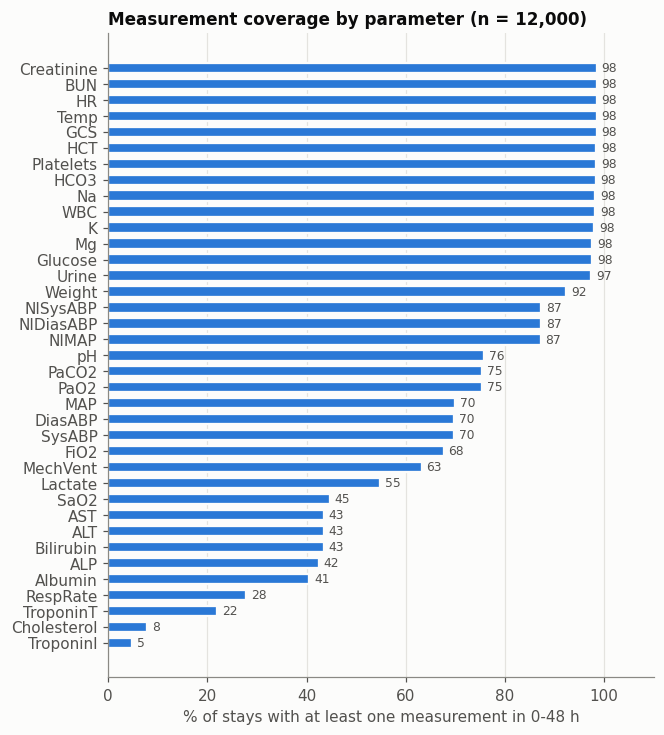

In [9]:
fdict = pd.read_csv(T2_PRE / "feature_dictionary.csv")
meas = fdict[(fdict.statistic == "measured") & (fdict.window == "0_48h") & ~fdict.feature_name.str.startswith("bp_")]
cov = pd.Series({r.source_parameter: Xm[r.feature_name].mean() * 100 for r in meas.itertuples()}).sort_values()
fig, ax = plt.subplots(figsize=(6.4, 7.6))
ax.barh(cov.index, cov.values, color=SERIES[0], height=0.65, edgecolor=SURFACE, linewidth=1.5)
for yy, v in enumerate(cov.values):
    ax.text(v + 1, yy, f"{v:.0f}", va="center", fontsize=8, color=INK2)
ax.set(xlabel="% of stays with at least one measurement in 0-48 h", xlim=(0, 110),
       title=f"Measurement coverage by parameter (n = {len(labels):,})")
ax.grid(axis="y", visible=False)
savefig(fig, "task2", "B3_measurement_coverage")

**Missingness carries information.** Labs are ordered when clinicians are worried, so *whether* something was measured is kept as features (`measured`, `count`, `time_span_hours`) rather than imputed away. TroponinI and cholesterol, for example, are measured in only 5–8 % of stays.

## B4 Pipelines, leakage control and the feature filter

**What is fitted, and on which rows:**

| Step | Fitted on | Used by |
|---|---|---|
| Train-only fill values (`X_*_imputed` files from B2) | training split | convenience artefacts only; the models below impute inside their own pipelines |
| `FeatureFilter`: drop constant, ≥ 99 % missing, near-duplicate (|r| ≥ 0.98) columns | training rows | first step of every L4 pipeline |
| Median imputation + standardisation | training rows (inside each CV fold during development) | logistic pipelines (L3, L3-revised) |
| SMOTE / under-sampling (when compared) | training rows of each fold only | never applied to validation or test |
| SHAP ranking for top-*k* selection | the training part of each CV fold | B6.3 |
| Threshold at recall 0.80 | validation | every rung |

The 37 × 3 × 12 summary grid is deliberately exhaustive, so it contains many near-copies. For example, `x__0_48h__first` equals `x__0_24h__first` whenever the variable was measured on day 1, and a variable's `measured` flag is identical across windows when it is measured on both days. The filter removes these redundancies before any model sees them.

In [10]:
t2_filter = t2m.feature_filter().fit(X_tr)
t2_rep = t2_filter.report()
print(f"FeatureFilter fitted on {len(X_tr):,} training stays: keeps {len(t2_filter.keep_)} of {X_tr.shape[1]} columns "
      f"({len([c for c in t2_filter.keep_ if c in DERIVED])} of {len(DERIVED)} derived features kept)")
display(t2_rep.rule.value_counts().rename("columns dropped").to_frame())
display(t2_rep.groupby("rule").head(4)[["feature", "reason"]].reset_index(drop=True))
Xf_tr, Xf_va, Xf_te = (t2_filter.transform(X) for X in (X_tr, X_va, X_te))

FeatureFilter fitted on 8,400 training stays: keeps 1163 of 1516 columns (38 of 42 derived features kept)


,columns dropped
rule,
near-duplicate,320
constant,30
mostly missing,3


,feature,reason
0,static_age_missing,constant
1,static_icutype_missing,constant
2,cholesterol__0_24h__slope_per_hour,missing >= 99%
3,mechvent__0_24h__first,constant
4,mechvent__0_24h__last,constant
5,troponini__24_48h__slope_per_hour,missing >= 99%
6,cholesterol__0_48h__slope_per_hour,missing >= 99%
7,static_bmi_missing,|r| >= 0.98 with static_height_missing
8,static_gender_1,|r| >= 0.98 with static_gender_0
9,alt__0_24h__count,|r| >= 0.98 with alp__0_24h__count


## B5 Baseline ladder L0–L3

Each rung has its threshold picked on validation (recall ≈ 0.80) and is scored on test once. The single-variable rungs impute a missing value with the training median.

In [11]:
ladder = []


def score_rung(rung, model, n_feat, s_val, s_test, y_val=None, y_test=None, n_boot=1000):
    """Test AUROC/AUPRC with stratified-bootstrap CI + Se/PPV/Sp at the validation recall-0.80 threshold."""
    y_val = y_va if y_val is None else y_val
    y_test = y_te if y_test is None else y_test
    thr = find_threshold_for_recall(y_val, s_val, target_recall=0.80)
    m_ = compute_metrics(y_test, s_test, threshold=thr)
    auc = strat_boot(y_test, s_test, roc_auc_score, n_bootstrap=n_boot)
    ap = strat_boot(y_test, s_test, average_precision_score, n_bootstrap=n_boot)
    row = {"rung": rung, "model": model, "features": n_feat, "n": len(y_test),
           "AUROC": auc[0], "AUROC lo": auc[1], "AUROC hi": auc[2], "AUPRC": ap[0], "AUPRC lo": ap[1], "AUPRC hi": ap[2],
           "threshold": thr, "Se": m_["sensitivity"], "PPV": m_["ppv"], "Sp": m_["specificity"], "min(Se,PPV)": m_["min_se_ppv"]}
    ladder.append(row)
    return row


def show(rows):
    t = pd.DataFrame(rows if isinstance(rows, list) else [rows])
    t["AUROC [95% CI]"] = [ci_str(*r) for r in t[["AUROC", "AUROC lo", "AUROC hi"]].to_numpy()]
    t["AUPRC [95% CI]"] = [ci_str(*r) for r in t[["AUPRC", "AUPRC lo", "AUPRC hi"]].to_numpy()]
    return t[["rung", "model", "features", "n", "AUROC [95% CI]", "AUPRC [95% CI]", "Se", "PPV", "Sp", "min(Se,PPV)"]].round(3)


# L0: random scores (no-skill floor)
rng = np.random.RandomState(SEED)
p_rand_te, p_rand_va = rng.uniform(size=len(y_te)), rng.uniform(size=len(y_va))
r0 = score_rung("L0", "random", 0, p_rand_va, p_rand_te)

# L1: one variable at a time (train-median imputed), oriented so a higher score means higher risk
L1 = {"age": ("static_age_years", +1), "GCS min (0-48 h)": ("gcs__0_48h__min", -1),
      "BUN max (0-48 h)": ("bun__0_48h__max", +1)}
r1 = []
for name, (col, sign) in L1.items():
    imp = SimpleImputer(strategy="median").fit(X_tr[[col]])
    r1.append(score_rung("L1", name, 1, sign * imp.transform(X_va[[col]]).ravel(), sign * imp.transform(X_te[[col]]).ravel()))
print(f"test prevalence (= no-skill AUPRC): {y_te.mean():.4f}")
show([r0] + r1)

test prevalence (= no-skill AUPRC): 0.1422


,rung,model,features,n,AUROC [95% CI],AUPRC [95% CI],Se,PPV,Sp,"min(Se,PPV)"
0,L0,random,0,1800,"0.479 [0.442, 0.516]","0.135 [0.123, 0.156]",0.746,0.14,0.24,0.14
1,L1,age,1,1800,"0.620 [0.586, 0.654]","0.198 [0.174, 0.227]",0.867,0.171,0.302,0.171
2,L1,GCS min (0-48 h),1,1800,"0.585 [0.551, 0.618]","0.164 [0.152, 0.179]",0.832,0.172,0.336,0.172
3,L1,BUN max (0-48 h),1,1800,"0.664 [0.627, 0.700]","0.236 [0.208, 0.277]",0.809,0.186,0.414,0.186


### L2: bedside severity scores (SAPS-I, SOFA)

In `outcomes.csv`, SAPS-I and SOFA use **`-1` for "not computable"**. Kept as a number, `-1` becomes the *lowest* score, but these stays are actually **higher** risk. So each score is evaluated on the stays where it exists, and later models are compared with it on that same subset.

In [12]:
te_lab, va_lab = lab.loc[ids_te], lab.loc[ids_va]
sentinel = {}
for score, key in (("SAPS-I", "saps_i"), ("SOFA", "sofa")):
    avail = te_lab[f"{key}_available"] == 1
    raw = te_lab[key].fillna(-1)
    s_med = te_lab[key].fillna(te_lab.loc[avail, key].median())
    sentinel[score] = {
        "test stays without a score": int((~avail).sum()),
        "mortality: without score / with score": f"{te_lab.loc[~avail, 'In-hospital_death'].mean():.3f} / "
                                                 f"{te_lab.loc[avail, 'In-hospital_death'].mean():.3f}",
        "AUROC keep -1 as a number": roc_auc_score(te_lab["In-hospital_death"], raw),
        "AUROC replace -1 by median": roc_auc_score(te_lab["In-hospital_death"], s_med),
        "AUROC score-available stays only": roc_auc_score(te_lab.loc[avail, "In-hospital_death"], te_lab.loc[avail, key]),
    }
print("Effect of the -1 sentinel (test):")
display(pd.DataFrame(sentinel).T)

r2 = []
for score, key in (("SAPS-I", "saps_i"), ("SOFA", "sofa")):
    mv, mt = va_lab[f"{key}_available"] == 1, te_lab[f"{key}_available"] == 1
    r2.append(score_rung("L2", score, "score", va_lab.loc[mv, key].to_numpy(), te_lab.loc[mt, key].to_numpy(),
                         y_val=y_va[mv.to_numpy()], y_test=y_te[mt.to_numpy()]))
show(r2)

Effect of the -1 sentinel (test):


,test stays without a score,mortality: without score / with score,AUROC keep -1 as a number,AUROC replace -1 by median,AUROC score-available stays only
SAPS-I,82,0.195 / 0.140,0.6262,0.6446,0.6516
SOFA,61,0.131 / 0.143,0.6226,0.6259,0.6294


,rung,model,features,n,AUROC [95% CI],AUPRC [95% CI],Se,PPV,Sp,"min(Se,PPV)"
0,L2,SAPS-I,score,1718,"0.652 [0.618, 0.687]","0.236 [0.205, 0.279]",0.767,0.176,0.415,0.176
1,L2,SOFA,score,1739,"0.629 [0.594, 0.667]","0.243 [0.208, 0.289]",0.843,0.176,0.345,0.176


### L3: eight-feature logistic regression (clinical-prior feature selection)

The first feature-selection method on the ladder is **knowledge-driven**. Eight features are chosen on clinical grounds, not by statistical screening. They cover the SOFA organ domains, the strongest L1 variables, and one measurement-behaviour signal: whether lactate was ordered at all.

Each logistic model is a pipeline that is fitted on training rows:

> column subset → median imputation → standardisation → (resampling) → L2-regularised logistic regression (C = 1)

**Class imbalance.** Before fitting, four strategies are compared by **5-fold stratified CV on the training split**. Any resampling happens inside each training fold only.

**Choosing a strategy.** We keep the simplest strategy whose mean CV AUPRC is within one standard error of the best. The order of simplicity is: none < class weights < under-sampling < SMOTE.

In [13]:
L3_FEATURES = {
    "bun__0_48h__max": "Renal: BUN peak (best L1 variable)",
    "static_age_years": "Demographic: physiological reserve",
    "gcs__0_48h__min": "CNS: worst GCS (as SOFA neuro uses)",
    "urine__0_48h__min": "Renal: worst oliguria",
    "lactate__0_48h__max": "Perfusion: peak lactate (shock)",
    "platelets__0_48h__min": "Coagulation: lowest platelets",
    "creatinine__0_48h__max": "Renal: creatinine peak (AKI)",
    "lactate__0_48h__measured": "Measurement behaviour: lactate ordered",
}
SIMPLICITY = ["none", "class_weight", "undersample", "smote"]


def simplest_within_1se(table, metric="AUPRC", n_folds=5):
    best = table[f"{metric} mean"].idxmax()
    floor = table.loc[best, f"{metric} mean"] - table.loc[best, f"{metric} sd"] / np.sqrt(n_folds)
    return next(s for s in SIMPLICITY if table.loc[s, f"{metric} mean"] >= floor)


imb_lr = t2m.imbalance_experiment(lambda s: t2m.logistic_pipeline(list(L3_FEATURES), s), X_tr, y_tr)
IMB_LR = simplest_within_1se(imb_lr)
imb_lr.to_csv(T2_RES / "imbalance_cv_logistic.csv")
print("class-imbalance strategies for the logistic models (5-fold CV on train):")
display(imb_lr.round(4))
print(f"-> kept: {IMB_LR}")

l3_pipe = t2m.logistic_pipeline(list(L3_FEATURES), IMB_LR).fit(X_tr, y_tr)
coef = pd.DataFrame({"rationale": L3_FEATURES.values(), "coefficient (per SD)": l3_pipe.named_steps["model"].coef_[0]},
                    index=L3_FEATURES.keys())
display(coef.round(3))
l3_proba = lambda X: l3_pipe.predict_proba(X)[:, 1]   # noqa: E731
fit_auc = {s: roc_auc_score(y, l3_proba(X)) for s, X, y in (("train", X_tr, y_tr), ("validation", X_va, y_va))}
print("train / validation AUROC:", {k: round(v, 4) for k, v in fit_auc.items()}, " -> small gap, no overfitting")
r3 = score_rung("L3", "logistic, 8 clinical-prior features", 8, l3_proba(X_va), l3_proba(X_te))
show(r3)

class-imbalance strategies for the logistic models (5-fold CV on train):


,AUROC mean,AUROC sd,AUPRC mean,AUPRC sd,Brier mean,Brier sd
none,0.7301,0.01,0.3364,0.0346,0.11,0.0025
class_weight,0.7304,0.0089,0.3351,0.0333,0.208,0.0018
smote,0.7299,0.0098,0.3355,0.0346,0.2081,0.0017
undersample,0.7308,0.0091,0.3319,0.0297,0.2088,0.0032


-> kept: none


,rationale,coefficient (per SD)
bun__0_48h__max,Renal: BUN peak (best L1 variable),0.542
static_age_years,Demographic: physiological reserve,0.304
gcs__0_48h__min,CNS: worst GCS (as SOFA neuro uses),-0.225
urine__0_48h__min,Renal: worst oliguria,-0.387
lactate__0_48h__max,Perfusion: peak lactate (shock),0.279
platelets__0_48h__min,Coagulation: lowest platelets,0.047
creatinine__0_48h__max,Renal: creatinine peak (AKI),-0.185
lactate__0_48h__measured,Measurement behaviour: lactate ordered,0.192


train / validation AUROC: {'train': 0.7322, 'validation': 0.7443}  -> small gap, no overfitting


,rung,model,features,n,AUROC [95% CI],AUPRC [95% CI],Se,PPV,Sp,"min(Se,PPV)"
0,L3,"logistic, 8 clinical-prior features",8,1800,"0.738 [0.705, 0.769]","0.363 [0.312, 0.418]",0.781,0.223,0.548,0.223


**Two coefficients carry counter-intuitive signs:** creatinine and platelets. Both are collinear with BUN and carry weak signal of their own. They are left as they are, because changing the feature set after seeing test would be a second look.

### Which *summary statistic* of a variable? GCS min vs GCS last (train + validation only)

L3 used the *minimum* GCS, because the SOFA neurological score uses the worst value. Before touching test, we screen every GCS statistic on train + validation (train-median imputed). Then we refit the L3 pipeline with the swaps, scoring validation only. This is the second feature-selection method on the ladder: **data-driven, univariate**.

In [14]:
y_tv = np.concatenate([y_tr, y_va])
gcs_screen = {}
for stat in ["last", "median", "mean", "max", "first", "slope_per_hour", "delta", "std", "min"]:
    col = f"gcs__0_48h__{stat}"
    imp = SimpleImputer(strategy="median").fit(X_tr[[col]])
    x = np.concatenate([imp.transform(X_tr[[col]]).ravel(), imp.transform(X_va[[col]]).ravel()])
    auc = roc_auc_score(y_tv, x)
    gcs_screen[stat] = {"AUROC (oriented)": max(auc, 1 - auc), "direction": "lower = riskier" if auc < 0.5 else "higher = riskier"}
print("Single-variable AUROC of each GCS statistic, train + validation:")
display(pd.DataFrame(gcs_screen).T)

orig = list(L3_FEATURES)
swap = {"gcs__0_48h__min": "gcs__0_48h__last", "urine__0_48h__min": "urine__0_48h__total"}
variants = {
    "A original (GCS min, urine min)": orig,
    "B GCS min -> last": [swap.get(f, f) if f.startswith("gcs") else f for f in orig],
    "C add GCS last, keep min": orig + ["gcs__0_48h__last"],
    "D urine min -> total": [swap.get(f, f) if f.startswith("urine") else f for f in orig],
    "E both swaps": [swap.get(f, f) for f in orig],
}
l3_variant_rows = {}
for name, fs in variants.items():
    pipe = t2m.logistic_pipeline(fs, IMB_LR).fit(X_tr, y_tr)
    pv = pipe.predict_proba(X_va)[:, 1]
    l3_variant_rows[name] = {"features": len(fs), "train AUROC": roc_auc_score(y_tr, pipe.predict_proba(X_tr)[:, 1]),
                      "validation AUROC": roc_auc_score(y_va, pv), "validation AUPRC": average_precision_score(y_va, pv)}
pd.DataFrame(l3_variant_rows).T.round(4)

Single-variable AUROC of each GCS statistic, train + validation:


,AUROC (oriented),direction
last,0.7525,lower = riskier
median,0.7165,lower = riskier
mean,0.7006,lower = riskier
max,0.6842,lower = riskier
first,0.5339,lower = riskier
slope_per_hour,0.6659,lower = riskier
delta,0.6656,lower = riskier
std,0.5271,lower = riskier
min,0.5838,lower = riskier


,features,train AUROC,validation AUROC,validation AUPRC
"A original (GCS min, urine min)",8,0.7322,0.7443,0.3174
B GCS min -> last,8,0.8116,0.8231,0.437
"C add GCS last, keep min",9,0.8222,0.8249,0.4398
D urine min -> total,8,0.746,0.7587,0.3655
E both swaps,8,0.8165,0.8276,0.4508


**L3-revised (pre-declared).** Variant E was selected on validation only. It is declared as a new rung, *L3-revised*, with its eight features fixed before test was scored, and is scored on test once. The original L3 stays on the ladder; it is not replaced.

In [15]:
L3R_FEATURES = variants["E both swaps"]
l3r_pipe = t2m.logistic_pipeline(L3R_FEATURES, IMB_LR).fit(X_tr, y_tr)
l3r_proba = lambda X: l3r_pipe.predict_proba(X)[:, 1]   # noqa: E731
r3r = score_rung("L3-revised", "logistic, 8 features (GCS last, urine total)", 8, l3r_proba(X_va), l3r_proba(X_te))
show([r3, r3r])

,rung,model,features,n,AUROC [95% CI],AUPRC [95% CI],Se,PPV,Sp,"min(Se,PPV)"
0,L3,"logistic, 8 clinical-prior features",8,1800,"0.738 [0.705, 0.769]","0.363 [0.312, 0.418]",0.781,0.223,0.548,0.223
1,L3-revised,"logistic, 8 features (GCS last, urine total)",8,1800,"0.815 [0.788, 0.842]","0.478 [0.428, 0.537]",0.75,0.296,0.705,0.296


## B6 L4: gradient-boosted trees, class imbalance, tuning and embedded feature selection

L4 starts from the filtered matrix (B4). Every step is decided on train, by stratified 5-fold CV, or on validation:

1. **Class imbalance (B6.1):** XGBoost with no weighting, `scale_pos_weight`, SMOTE (median-impute then oversample), or random under-sampling, compared by CV on train. The choice uses the same simplest-within-one-SE rule as B5.
2. **Filter check (B6.1):** XGBoost on all 1,516 columns vs the 1,159 filtered ones, by CV.
3. **Hyperparameter search (B6.2):** 50 random configurations × 5-fold CV on train, scored by AUPRC.
4. **Embedded feature selection (B6.3):** features are ranked by mean |SHAP| of XGBoost and the model is refitted on the top *k*. The ranking is relearned inside every CV fold (**nested**), so the held-out fold never influences which features are kept. *k* is the smallest value within one SE of the best.
5. **Final fits and model selection (B6.4):**
   * The final XGBoost pipeline is filter → top-*k* selector → XGBoost, fitted on train.
   * CatBoost, the runner-up, gets the filter and then CatBoost with native class weights and early stopping on validation. Its hyperparameters come from the original 50-candidate GPU search (`docs/task2_mortality/original_results/`).
   * Validation AUPRC picks between the two.

With `RETRAIN_TASK2 = False`, steps 1–5 load their logged results and the fitted pipelines instead of recomputing them.

In [16]:
SPW = (len(y_tr) - y_tr.sum()) / y_tr.sum()
V1_XGB = {"subsample": 0.9, "n_estimators": 300, "min_child_weight": 3, "max_depth": 7, "max_bin": 127,
          "learning_rate": 0.05, "gamma": 0, "colsample_bytree": 0.9}     # v1 search result: starting point for B6.1
IMB_CSV, FILTER_CSV = T2_RES / "imbalance_cv_xgboost.csv", T2_RES / "filter_ablation_cv.csv"

if RETRAIN_TASK2:
    t0 = time.time()
    imb_xgb = t2m.imbalance_experiment(
        lambda s: t2m.xgb_pipeline(V1_XGB, s, SPW, use_filter=False, device=DEVICE), Xf_tr, y_tr)
    imb_xgb.to_csv(IMB_CSV)
    IMB_XGB = simplest_within_1se(imb_xgb)
    filt_abl = pd.DataFrame({
        f"all {X_tr.shape[1]} columns": t2m.cv_evaluate(t2m.xgb_pipeline(V1_XGB, IMB_XGB, SPW, use_filter=False, device=DEVICE), X_tr, y_tr),
        f"{Xf_tr.shape[1]} filtered columns": t2m.cv_evaluate(t2m.xgb_pipeline(V1_XGB, IMB_XGB, SPW, use_filter=False, device=DEVICE), Xf_tr, y_tr),
    }).T
    filt_abl.to_csv(FILTER_CSV)
    print(f"B6.1 computed in {(time.time() - t0) / 60:.1f} min")
else:
    imb_xgb, filt_abl = pd.read_csv(IMB_CSV, index_col=0), pd.read_csv(FILTER_CSV, index_col=0)
    IMB_XGB = simplest_within_1se(imb_xgb)
print("B6.1 class-imbalance strategies for XGBoost (5-fold CV on train, filtered columns):")
display(imb_xgb.round(4))
print(f"-> kept: {IMB_XGB}")
print("Feature filter check (5-fold CV on train):")
display(filt_abl.round(4))

B6.1 class-imbalance strategies for XGBoost (5-fold CV on train, filtered columns):


,AUROC mean,AUROC sd,AUPRC mean,AUPRC sd,Brier mean,Brier sd
none,0.8804,0.008,0.5791,0.0266,0.0886,0.0027
class_weight,0.877,0.0059,0.5726,0.0247,0.0889,0.0029
smote,0.8746,0.0051,0.5608,0.0166,0.0888,0.0019
undersample,0.874,0.0088,0.5577,0.026,0.163,0.0072


-> kept: none
Feature filter check (5-fold CV on train):


,AUROC mean,AUROC sd,AUPRC mean,AUPRC sd,Brier mean,Brier sd
all 1516 columns,0.8808,0.0088,0.5766,0.0251,0.089,0.0034
1163 filtered columns,0.8804,0.008,0.5791,0.0266,0.0886,0.0027


In [17]:
XGB_SPACE = {"max_depth": [3, 5, 7, 9], "learning_rate": [0.01, 0.05, 0.1], "n_estimators": [100, 200, 300, 500],
             "min_child_weight": [1, 3, 5], "subsample": [0.8, 0.9, 1.0], "colsample_bytree": [0.8, 0.9, 1.0],
             "gamma": [0, 0.1, 0.2], "max_bin": [63, 127, 255]}
SEARCH_JSON, SEARCH_CSV = T2_RES / "L4_xgboost_search.json", T2_RES / "L4_xgboost_search_all_candidates.csv"

if RETRAIN_TASK2:
    t0 = time.time()
    search = RandomizedSearchCV(t2m.xgb_pipeline({}, IMB_XGB, SPW, use_filter=False, device=DEVICE),
                                {f"model__{k}": v for k, v in XGB_SPACE.items()}, n_iter=50,
                                scoring="average_precision", cv=t2m.cv_folds(), random_state=SEED, n_jobs=1, refit=False)
    search.fit(Xf_tr, y_tr)
    cvr = pd.DataFrame(search.cv_results_)
    pcols = [c for c in cvr.columns if c.startswith("param_model__")]
    allc = cvr[pcols + ["mean_test_score", "std_test_score"] + [f"split{i}_test_score" for i in range(5)]
               + ["mean_fit_time", "rank_test_score"]].copy()
    allc.columns = ([c.replace("param_model__", "") for c in pcols] + ["mean_cv_auprc", "sd_cv_auprc"]
                    + [f"fold{i + 1}_auprc" for i in range(5)] + ["mean_fit_seconds", "rank"])
    allc.sort_values("rank").to_csv(SEARCH_CSV, index=False)          # every candidate, every fold
    search_log = {"best_params": {k.replace("model__", ""): v for k, v in search.best_params_.items()},
                  "best_cv_auprc": float(search.best_score_), "imbalance": IMB_XGB, "device": DEVICE,
                  "n_candidates": 50, "cv_folds": 5, "scoring": "average_precision", "random_state": SEED,
                  "minutes": (time.time() - t0) / 60}
    SEARCH_JSON.write_text(json.dumps(search_log, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o)))
search_log = json.loads(SEARCH_JSON.read_text())
xgb_candidates = pd.read_csv(SEARCH_CSV)
BEST_XGB = search_log["best_params"]
print(f"B6.2 hyperparameter search: {len(xgb_candidates)} candidates x 5 folds on train "
      f"({search_log['device']}, {search_log['minutes']:.1f} min). Every candidate, ranked by mean CV AUPRC:")
with pd.option_context("display.max_rows", 60):
    display(xgb_candidates.round(4))
print("selected:", BEST_XGB, f"(CV AUPRC {search_log['best_cv_auprc']:.4f})")

B6.2 hyperparameter search: 50 candidates x 5 folds on train (cuda, 45.5 min). Every candidate, ranked by mean CV AUPRC:


,subsample,n_estimators,min_child_weight,max_depth,max_bin,learning_rate,gamma,colsample_bytree,mean_cv_auprc,sd_cv_auprc,fold1_auprc,fold2_auprc,fold3_auprc,fold4_auprc,fold5_auprc,mean_fit_seconds,rank
0,0.9,200,5,9,127,0.05,0.2,1,0.5834,0.0245,0.5721,0.6147,0.5527,0.6101,0.5677,12.5565,1
1,0.9,500,5,7,63,0.05,0,0.9,0.583,0.0188,0.5621,0.6025,0.5731,0.6085,0.5686,11.7933,2
2,0.9,500,5,7,255,0.01,0.1,0.9,0.5827,0.0275,0.5638,0.6198,0.5616,0.6126,0.556,31.5248,3
3,0.8,500,1,5,127,0.01,0,0.8,0.582,0.025,0.5733,0.6171,0.5679,0.6035,0.5481,16.3604,4
4,0.9,300,5,3,255,0.05,0.1,0.8,0.5797,0.0289,0.5563,0.6195,0.5568,0.6105,0.5556,6.2236,5
5,0.9,500,5,9,63,0.01,0.2,0.8,0.5793,0.0278,0.5526,0.6199,0.5624,0.6054,0.556,18.2579,6
6,0.9,300,3,7,127,0.05,0,0.9,0.5791,0.0266,0.5587,0.612,0.56,0.6111,0.5538,13.1315,7
7,0.8,300,1,9,63,0.05,0,1,0.5789,0.0235,0.5624,0.6186,0.5574,0.5932,0.5631,15.996,8
8,0.9,500,3,5,127,0.01,0.1,1,0.5778,0.0311,0.5509,0.6205,0.5572,0.6105,0.5496,16.2609,9
9,1,300,5,9,255,0.05,0,0.8,0.577,0.0238,0.5577,0.6024,0.5502,0.6084,0.5663,19.7378,10


selected: {'subsample': 0.9, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 9, 'max_bin': 127, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0} (CV AUPRC 0.5834)


B6.3 nested-CV top-k selection (AUPRC): chosen k = 100 of 1163 filtered features


,AUROC,mean,std,count,se,within_1se
k,,,,,,
25,0.8597,0.5317,0.0348,5,0.0156,False
50,0.8691,0.5416,0.0292,5,0.0131,False
100,0.8784,0.564,0.0235,5,0.0105,True
200,0.881,0.5737,0.0267,5,0.0119,True
400,0.8796,0.5706,0.0281,5,0.0126,True
1163,0.8772,0.5721,0.0262,5,0.0117,True


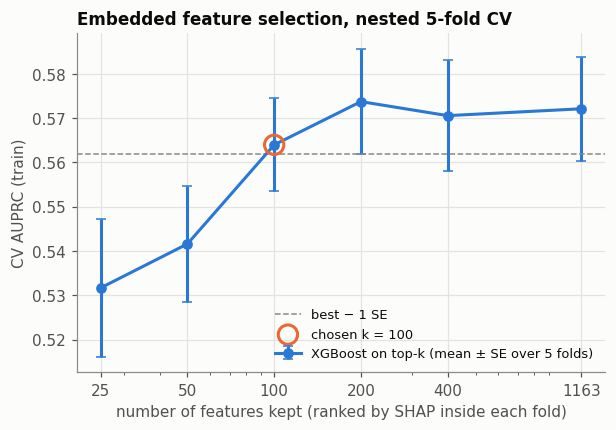

In [18]:
TOPK_CSV, SELECTED_JSON = T2_RES / "topk_nested_cv.csv", T2_MODELS / "L4_selected_features.json"
KS = [25, 50, 100, 200, 400, None]

if RETRAIN_TASK2:
    t0 = time.time()
    topk_cv = t2m.topk_nested_cv(Xf_tr, y_tr, BEST_XGB, IMB_XGB, SPW, KS, device=DEVICE)
    topk_cv.to_csv(TOPK_CSV, index=False)
    K_CHOSEN, _ = t2m.one_se_choice(topk_cv, "AUPRC")
    full_model = t2m.xgb_pipeline(BEST_XGB, IMB_XGB, SPW, use_filter=False, device=DEVICE).fit(Xf_tr, y_tr)
    ranking = t2m.shap_ranking(full_model.named_steps["model"], Xf_tr)        # final ranking: whole training split
    SELECTED_JSON.write_text(json.dumps({"k": K_CHOSEN, "features": ranking[:K_CHOSEN], "ranking": ranking}, indent=2))
    print(f"B6.3 computed in {(time.time() - t0) / 60:.1f} min")
topk_cv = pd.read_csv(TOPK_CSV)
K_CHOSEN, topk_tbl = t2m.one_se_choice(topk_cv, "AUPRC")
SELECTED = json.loads(SELECTED_JSON.read_text())["features"]
print(f"B6.3 nested-CV top-k selection (AUPRC): chosen k = {K_CHOSEN} of {Xf_tr.shape[1]} filtered features")
display(topk_cv.groupby("k")[["AUROC"]].mean().join(topk_tbl).round(4))

fig, ax = plt.subplots(figsize=(6.2, 4))
ax.errorbar(topk_tbl.index, topk_tbl["mean"], yerr=topk_tbl["se"], color=SERIES[0], marker="o", capsize=3,
            label="XGBoost on top-k (mean ± SE over 5 folds)")
ax.axhline(topk_tbl["mean"].max() - topk_tbl.loc[topk_tbl["mean"].idxmax(), "se"], color=BASELINE, ls="--", lw=1,
           label="best − 1 SE")
ax.scatter([K_CHOSEN], [topk_tbl.loc[K_CHOSEN, "mean"]], s=160, facecolor="none", edgecolor=SERIES[1], linewidth=2,
           zorder=4, label=f"chosen k = {K_CHOSEN}")
ax.set(xscale="log", xlabel="number of features kept (ranked by SHAP inside each fold)", ylabel="CV AUPRC (train)",
       title="Embedded feature selection, nested 5-fold CV")
ax.set_xticks(topk_tbl.index); ax.set_xticklabels(topk_tbl.index)
ax.legend(fontsize=8.5, loc="lower right")
savefig(fig, "task2", "B6_topk_nested_cv")

In [19]:
XGB_PIPE, CB_PIPE = T2_MODELS / "L4_xgboost_pipeline.joblib", T2_MODELS / "L4_catboost_pipeline.joblib"
CB_PARAMS = {"depth": 8, "learning_rate": 0.03, "l2_leaf_reg": 9, "border_count": 128,
             "random_strength": 0.5, "bagging_temperature": 1.0}       # from the v1 50-candidate GPU search
CB_SPACE = {"depth": [4, 6, 8], "learning_rate": [0.01, 0.03, 0.05, 0.1], "iterations": [200, 300, 500],
            "l2_leaf_reg": [1, 3, 5, 9], "border_count": [32, 64, 128], "random_strength": [0.5, 1, 3],
            "bagging_temperature": [0, 0.5, 1]}
cb_ckpt = pd.DataFrame(json.loads((ROOT / "docs/task2_mortality/original_results/L4_catboost_search_checkpoint.json")
                                  .read_text())["results"])
cb_candidates = (pd.concat([cb_ckpt.params.apply(pd.Series), cb_ckpt[["mean_cv_auroc", "std_cv_auroc"]]], axis=1)
                 .sort_values("mean_cv_auroc", ascending=False).reset_index(drop=True))
print("CatBoost hyperparameters: best of the original 50-candidate x 5-fold CV search (top 5 shown; all 50 in the tuning log):")
display(cb_candidates.head(5).round(4))

if RETRAIN_TASK2:
    t0 = time.time()
    xgb_pipe = t2m.xgb_pipeline(BEST_XGB, IMB_XGB, SPW, columns=SELECTED, device=DEVICE).fit(X_tr, y_tr)
    xgb_pipe.named_steps["model"].set_params(device="cpu")             # portable: predicts on any machine
    xgb_pipe.named_steps["model"].save_model(str(T2_MODELS / "L4_xgboost_booster.json"))
    joblib.dump(xgb_pipe, XGB_PIPE)
    cb = CatBoostClassifier(**CB_PARAMS, iterations=2000, loss_function="Logloss", eval_metric="PRAUC",
                            auto_class_weights=None if IMB_XGB == "none" else "Balanced",
                            random_seed=SEED, verbose=False, allow_writing_files=False)
    cb.fit(Xf_tr, y_tr, eval_set=(Xf_va, y_va), early_stopping_rounds=50)
    cb_pipe = Pipeline([("filter", t2_filter), ("model", cb)])
    joblib.dump(cb_pipe, CB_PIPE)
    print(f"B6.4 final fits in {(time.time() - t0) / 60:.1f} min")
xgb_pipe, cb_pipe = joblib.load(XGB_PIPE), joblib.load(CB_PIPE)

p_l4 = {name: {s: pipe.predict_proba(X)[:, 1] for s, X in (("train", X_tr), ("validation", X_va))}
        for name, pipe in (("XGBoost", xgb_pipe), ("CatBoost", cb_pipe))}
sel = pd.DataFrame({name: {"features used": n, "validation AUROC": roc_auc_score(y_va, p["validation"]),
                           "validation AUPRC": average_precision_score(y_va, p["validation"])}
                    for (name, p), n in zip(p_l4.items(), (len(SELECTED), len(t2_filter.keep_)))}).T
SELECTED_MODEL = sel["validation AUPRC"].astype(float).idxmax()
print(f"model selection on validation AUPRC -> {SELECTED_MODEL}")
display(sel)

cap_rows = {}
for name, pipe in (("XGBoost", xgb_pipe), ("CatBoost", cb_pipe)):
    p = p_l4[name]
    n_trees = pipe.named_steps["model"].get_booster().num_boosted_rounds() if name == "XGBoost" else pipe.named_steps["model"].tree_count_
    cap_rows[name] = {"trees": n_trees, "train AUROC": roc_auc_score(y_tr, p["train"]),
                      "validation AUROC": roc_auc_score(y_va, p["validation"]),
                      "train AUPRC": average_precision_score(y_tr, p["train"]),
                      "validation AUPRC": average_precision_score(y_va, p["validation"])}
cap_rows["L3-revised logistic (reference)"] = {"trees": np.nan, "train AUROC": roc_auc_score(y_tr, l3r_proba(X_tr)),
                                               "validation AUROC": roc_auc_score(y_va, l3r_proba(X_va)),
                                               "train AUPRC": average_precision_score(y_tr, l3r_proba(X_tr)),
                                               "validation AUPRC": average_precision_score(y_va, l3r_proba(X_va))}
cap = pd.DataFrame(cap_rows).T
cap["AUROC gap (train − val)"] = cap["train AUROC"] - cap["validation AUROC"]
print("Capacity check (train vs validation; test untouched):")
display(cap.round(4))

CatBoost hyperparameters: best of the original 50-candidate x 5-fold CV search (top 5 shown; all 50 in the tuning log):


,depth,learning_rate,iterations,l2_leaf_reg,border_count,random_strength,bagging_temperature,mean_cv_auroc,std_cv_auroc
0,8,0.03,500,9,128,0.5,1,0.8674,0.0055
1,8,0.05,300,9,32,0.5,0.5,0.866,0.0082
2,4,0.03,500,9,128,0.5,1,0.8658,0.0072
3,8,0.03,500,5,128,3,0,0.8657,0.0078
4,4,0.05,300,1,32,0.5,1,0.8656,0.0077


model selection on validation AUPRC -> CatBoost

,features used,validation AUROC,validation AUPRC
XGBoost,100,0.8626,0.5224
CatBoost,1163,0.8714,0.544


Capacity check (train vs validation; test untouched):


,trees,train AUROC,validation AUROC,train AUPRC,validation AUPRC,AUROC gap (train − val)
XGBoost,200,1,0.8626,1,0.5224,0.1374
CatBoost,341,0.9844,0.8714,0.9523,0.544,0.1129
L3-revised logistic (reference),NaN,0.8165,0.8276,0.471,0.4508,-0.0111


## B7 Test evaluation of L4: the single test look

The selected pipeline (B6.4) is scored on test once. Its threshold comes from validation (recall ≈ 0.80).

In [20]:
final_pipe = xgb_pipe if SELECTED_MODEL == "XGBoost" else cb_pipe
p4_va = final_pipe.predict_proba(X_va)[:, 1]
p4_te = final_pipe.predict_proba(X_te)[:, 1]
n_l4 = len(SELECTED) if SELECTED_MODEL == "XGBoost" else len(t2_filter.keep_)
r4 = score_rung("L4", f"{SELECTED_MODEL}, {n_l4} selected features", n_l4, p4_va, p4_te)
ladder_tbl = show(ladder)
ladder_tbl.to_csv(T2_RES / "ladder_test.csv", index=False)
print("Baseline ladder, TEST (Se/PPV/Sp at the validation recall-0.80 threshold; L2 on score-available stays):")
display(ladder_tbl)

tn, fp, fn, tp = confusion_matrix(y_te, (p4_te >= r4["threshold"]).astype(int)).ravel()
print(f"L4 at threshold {r4['threshold']:.3f}: flags {tp + fp} of {len(y_te)} patients ({100 * (tp + fp) / len(y_te):.0f} %); "
      f"{tp} of {tp + fp} flagged die ({100 * tp / (tp + fp):.1f} % vs base rate {100 * y_te.mean():.1f} %); "
      f"misses {fn} of {tp + fn} deaths")
display(pd.DataFrame([[tp, fn], [fp, tn]], index=["died", "survived"], columns=["flagged", "not flagged"]))

Baseline ladder, TEST (Se/PPV/Sp at the validation recall-0.80 threshold; L2 on score-available stays):


,rung,model,features,n,AUROC [95% CI],AUPRC [95% CI],Se,PPV,Sp,"min(Se,PPV)"
0,L0,random,0,1800,"0.479 [0.442, 0.516]","0.135 [0.123, 0.156]",0.746,0.14,0.24,0.14
1,L1,age,1,1800,"0.620 [0.586, 0.654]","0.198 [0.174, 0.227]",0.867,0.171,0.302,0.171
2,L1,GCS min (0-48 h),1,1800,"0.585 [0.551, 0.618]","0.164 [0.152, 0.179]",0.832,0.172,0.336,0.172
3,L1,BUN max (0-48 h),1,1800,"0.664 [0.627, 0.700]","0.236 [0.208, 0.277]",0.809,0.186,0.414,0.186
4,L2,SAPS-I,score,1718,"0.652 [0.618, 0.687]","0.236 [0.205, 0.279]",0.767,0.176,0.415,0.176
5,L2,SOFA,score,1739,"0.629 [0.594, 0.667]","0.243 [0.208, 0.289]",0.843,0.176,0.345,0.176
6,L3,"logistic, 8 clinical-prior features",8,1800,"0.738 [0.705, 0.769]","0.363 [0.312, 0.418]",0.781,0.223,0.548,0.223
7,L3-revised,"logistic, 8 features (GCS last, urine total)",8,1800,"0.815 [0.788, 0.842]","0.478 [0.428, 0.537]",0.75,0.296,0.705,0.296
8,L4,"CatBoost, 1163 selected features",1163,1800,"0.864 [0.842, 0.884]","0.570 [0.519, 0.625]",0.754,0.362,0.78,0.362


L4 at threshold 0.144: flags 533 of 1800 patients (30 %); 193 of 533 flagged die (36.2 % vs base rate 14.2 %); misses 63 of 256 deaths


,flagged,not flagged
died,193,63
survived,340,1204


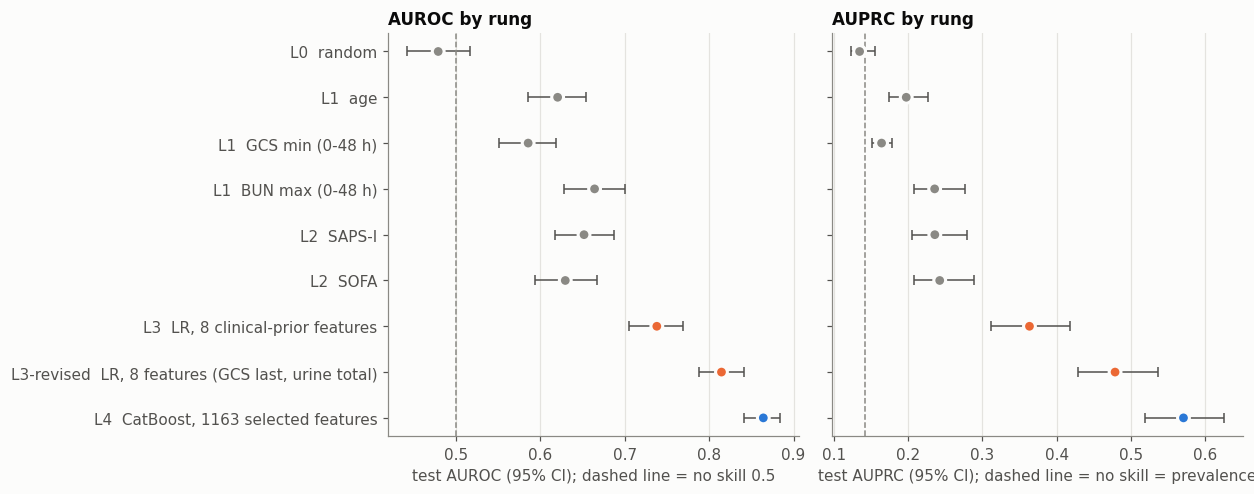

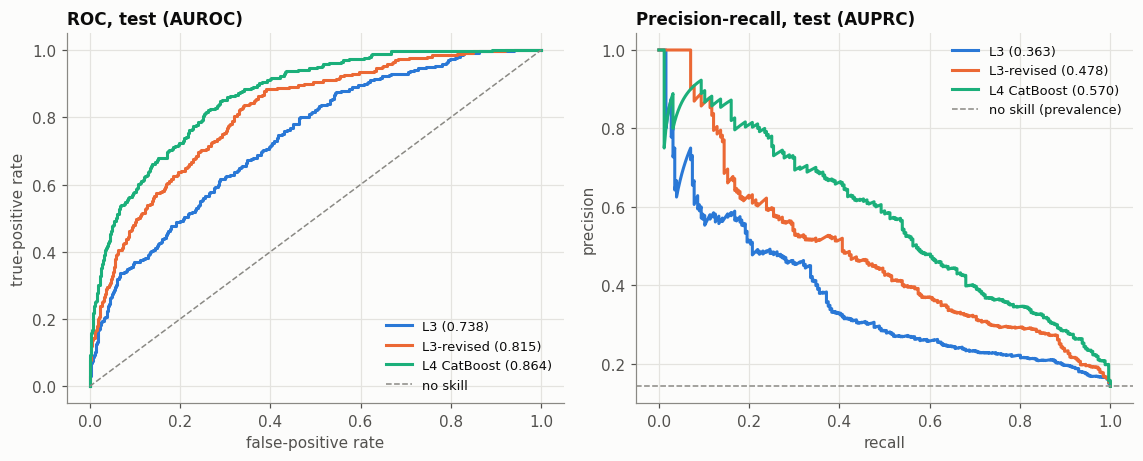

In [21]:
lt = pd.DataFrame(ladder)
lt["label"] = lt.rung + "  " + lt.model.str.replace("logistic, ", "LR, ")
fig, axes_ = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)
ypos = np.arange(len(lt))[::-1]
for ax, metric, ref, ref_lbl in ((axes_[0], "AUROC", 0.5, "no skill 0.5"), (axes_[1], "AUPRC", y_te.mean(), "no skill = prevalence")):
    colors = [SERIES[0] if r == "L4" else (SERIES[1] if r.startswith("L3") else BASELINE) for r in lt.rung]
    ax.errorbar(lt[metric], ypos, xerr=[lt[metric] - lt[f"{metric} lo"], lt[f"{metric} hi"] - lt[metric]],
                fmt="none", ecolor=INK2, elinewidth=1, capsize=3)
    ax.scatter(lt[metric], ypos, color=colors, s=60, zorder=3, edgecolor=SURFACE, linewidth=2)
    ax.axvline(ref, color=BASELINE, ls="--", lw=1)
    ax.set(xlabel=f"test {metric} (95% CI); dashed line = {ref_lbl}", title=f"{metric} by rung")
    ax.grid(axis="y", visible=False)
axes_[0].set_yticks(ypos); axes_[0].set_yticklabels(lt.label)
fig.tight_layout()
savefig(fig, "task2", "B7_ladder_test")

fig, axes_ = plt.subplots(1, 2, figsize=(10.5, 4.3))
for (name, s), color in zip((("L3", l3_proba(X_te)), ("L3-revised", l3r_proba(X_te)), ("L4 " + SELECTED_MODEL, p4_te)), SERIES[:3]):
    fpr, tpr, _ = roc_curve(y_te, s); prec, rec, _ = precision_recall_curve(y_te, s)
    axes_[0].plot(fpr, tpr, color=color, label=f"{name} ({roc_auc_score(y_te, s):.3f})")
    axes_[1].plot(rec, prec, color=color, label=f"{name} ({average_precision_score(y_te, s):.3f})")
axes_[0].plot([0, 1], [0, 1], color=BASELINE, ls="--", lw=1, label="no skill")
axes_[1].axhline(y_te.mean(), color=BASELINE, ls="--", lw=1, label="no skill (prevalence)")
axes_[0].set(xlabel="false-positive rate", ylabel="true-positive rate", title="ROC, test (AUROC)")
axes_[1].set(xlabel="recall", ylabel="precision", title="Precision-recall, test (AUPRC)")
for ax in axes_:
    ax.legend(fontsize=8.5)
fig.tight_layout()
savefig(fig, "task2", "B7_roc_pr_test")

In [22]:
h2h = {}
for score, key in (("SAPS-I", "saps_i"), ("SOFA", "sofa")):
    mt = (te_lab[f"{key}_available"] == 1).to_numpy()
    yb = y_te[mt]
    b = strat_boot(yb, te_lab.loc[mt, key].to_numpy(), roc_auc_score)
    l4 = strat_boot(yb, p4_te[mt], roc_auc_score)
    h2h[f"vs {score} (n = {mt.sum():,})"] = {"bedside AUROC [CI]": ci_str(*b), "L4 AUROC [CI]": ci_str(*l4),
                                             "gain": l4[0] - b[0], "CIs overlap": not (l4[1] > b[2] or l4[2] < b[1])}
print("Head-to-head on each bedside score's own patients (test):")
pd.DataFrame(h2h).T

Head-to-head on each bedside score's own patients (test):


,bedside AUROC [CI],L4 AUROC [CI],gain,CIs overlap
"vs SAPS-I (n = 1,718)","0.652 [0.618, 0.687]","0.868 [0.845, 0.889]",0.2167,False
"vs SOFA (n = 1,739)","0.629 [0.594, 0.667]","0.866 [0.845, 0.888]",0.2368,False


## B8 Calibration and subgroups (frozen test predictions)

These analyses use the test prediction vector that was already scored in B7. They involve no retraining and no new choices, so they are not a second look.

Brier score (test): 0.0869  (constant-prevalence predictor: 0.1220)


,mean predicted,observed death rate
0,0.034,0.034
1,0.142,0.172
2,0.245,0.23
3,0.351,0.375
4,0.445,0.54
5,0.551,0.591
6,0.642,0.743
7,0.753,0.941
8,0.849,0.8
9,0.951,1


,ICU type,n,deaths,prevalence,AUROC,lo,hi
0,Coronary care,269,35,0.13,0.853,0.792,0.905
1,Cardiac surgery recovery,382,21,0.055,0.895,0.815,0.953
2,Medical,623,118,0.189,0.816,0.771,0.856
3,Surgical,526,82,0.156,0.877,0.838,0.913


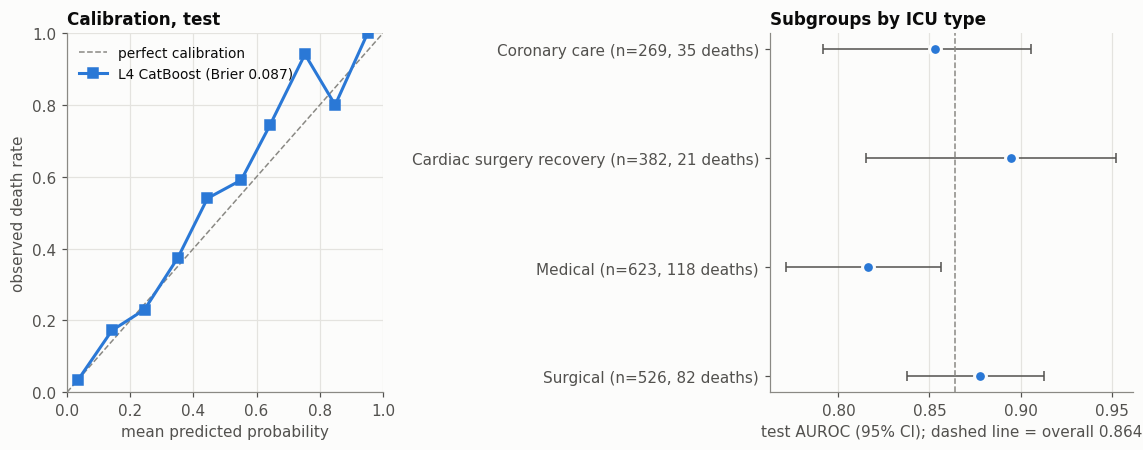

In [23]:
frac_pos, mean_pred = calibration_curve(y_te, p4_te, n_bins=10, strategy="uniform")
print(f"Brier score (test): {brier_score_loss(y_te, p4_te):.4f}  (constant-prevalence predictor: {y_te.mean() * (1 - y_te.mean()):.4f})")
display(pd.DataFrame({"mean predicted": mean_pred, "observed death rate": frac_pos}).round(3))

icu_names = {1: "Coronary care", 2: "Cardiac surgery recovery", 3: "Medical", 4: "Surgical"}
sg = []
for k, name in icu_names.items():
    msk = X_te[f"static_icutype_{k}"].to_numpy() == 1
    auc = strat_boot(y_te[msk], p4_te[msk], roc_auc_score)
    sg.append({"ICU type": name, "n": int(msk.sum()), "deaths": int(y_te[msk].sum()), "prevalence": y_te[msk].mean(),
               "AUROC": auc[0], "lo": auc[1], "hi": auc[2]})
sg = pd.DataFrame(sg)
display(sg.round(3))

fig, axes_ = plt.subplots(1, 2, figsize=(10.5, 4.2), gridspec_kw={"width_ratios": [1, 1.15]})
ax = axes_[0]
ax.plot([0, 1], [0, 1], color=BASELINE, ls="--", lw=1, label="perfect calibration")
ax.plot(mean_pred, frac_pos, color=SERIES[0], marker="s", label=f"L4 {SELECTED_MODEL} (Brier {brier_score_loss(y_te, p4_te):.3f})")
ax.set(xlabel="mean predicted probability", ylabel="observed death rate", title="Calibration, test", xlim=(0, 1), ylim=(0, 1))
ax.legend(fontsize=9, loc="upper left")
ax = axes_[1]
ypos = np.arange(len(sg))[::-1]
ax.errorbar(sg.AUROC, ypos, xerr=[sg.AUROC - sg.lo, sg.hi - sg.AUROC], fmt="none", ecolor=INK2, elinewidth=1, capsize=3)
ax.scatter(sg.AUROC, ypos, color=SERIES[0], s=60, zorder=3, edgecolor=SURFACE, linewidth=2)
ax.axvline(r4["AUROC"], color=BASELINE, ls="--", lw=1)
ax.set(yticks=ypos, yticklabels=[f"{r['ICU type']} (n={r.n}, {r.deaths} deaths)" for _, r in sg.iterrows()],
       xlabel=f"test AUROC (95% CI); dashed line = overall {r4['AUROC']:.3f}", title="Subgroups by ICU type")
ax.grid(axis="y", visible=False)
fig.tight_layout()
savefig(fig, "task2", "B8_calibration_subgroups_test")

## B9 Interpretation: what the model learned

SHAP values come from exact TreeSHAP on the test set, the frozen prediction vector, over the columns the final pipeline actually uses. We also check whether the other gradient-boosting model agrees on what matters, computing SHAP on *validation*, because the model that lost selection must never be scored on test.

,mean |SHAP|,organ,statistic type,derived (v2)
gcs__0_48h__last,0.233,CNS,point in time,
static_age_years,0.213,demographic / context,static / score,
gcs__24_48h__max,0.137,CNS,extreme,
organ_score__24_48h__total,0.099,multi-organ (derived),cumulative,yes
urine__0_48h__total,0.091,renal,cumulative,
shock_index__0_48h__last,0.074,cardiovascular,point in time,yes
bun_cr_ratio__0_24h__last,0.069,renal,point in time,yes
bun_cr_ratio__0_48h__last,0.062,renal,point in time,yes
bun__0_48h__last,0.06,renal,point in time,
gcs__0_48h__std,0.058,CNS,variability,


derived (v2) features among the top 20: 4 | statistic types: {'point in time': 6, 'central': 4, 'extreme': 3, 'trend': 3, 'cumulative': 2, 'static / score': 1, 'variability': 1}


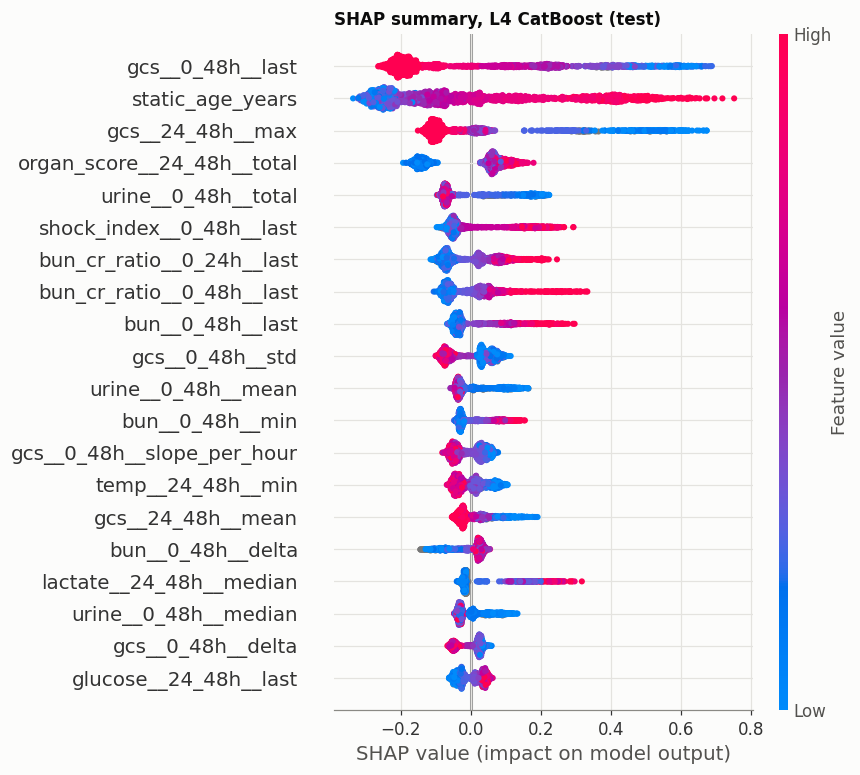

In [24]:
def pipe_shap(pipe, X):
    """(SHAP values, base values, transformed X) for the columns the pipeline's model sees."""
    Xt = pipe[:-1].transform(X)
    mdl = pipe.named_steps["model"]
    if isinstance(mdl, xgb.XGBClassifier):
        c = mdl.get_booster().predict(xgb.DMatrix(Xt), pred_contribs=True)
    else:
        c = mdl.get_feature_importance(Pool(Xt), type="ShapValues")
    return c[:, :-1], c[:, -1], Xt


def stat_type(n):
    for key, lab_ in (("measured", "measurement behaviour"), ("__count", "measurement behaviour"),
                      ("time_span_hours", "measurement behaviour"), ("slope_per_hour", "trend"), ("__delta", "trend"),
                      ("delta_total", "trend"), ("__std", "variability"), ("__first", "point in time"),
                      ("__last", "point in time"), ("__min", "extreme"), ("__max", "extreme"), ("__mean", "central"),
                      ("__median", "central"), ("__total", "cumulative"), ("urine_ml_kg_h", "cumulative")):
        if key in n:
            return lab_
    return "static / score"


def organ(n):
    n = n.lower()
    for keys, lab_ in ((["organ_score"], "multi-organ (derived)"), (["bun", "creatinine", "urine"], "renal"), (["gcs"], "CNS"),
                       (["lactate", "bp_", "sysabp", "diasabp", "map", "hr__", "shock_index"], "cardiovascular"),
                       (["platelets", "wbc", "hct"], "haematology"), (["bilirubin", "alt", "ast", "alp", "albumin"], "hepatic"),
                       (["pao2", "paco2", "fio2", "sao2", "mechvent", "resprate", "pf_ratio"], "respiratory"),
                       (["age", "gender", "icutype", "bmi", "height", "weight"], "demographic / context"),
                       (["record__"], "record-level")):
        if any(k in n for k in keys):
            return lab_
    return "other lab"


shap_te, base_te, Xt_te = pipe_shap(final_pipe, X_te)
mean_abs = pd.Series(np.abs(shap_te).mean(0), index=Xt_te.columns).sort_values(ascending=False)
top20 = mean_abs.head(20).rename("mean |SHAP|").to_frame()
top20["organ"] = [organ(f) for f in top20.index]
top20["statistic type"] = [stat_type(f) for f in top20.index]
top20["derived (v2)"] = ["yes" if f in DERIVED else "" for f in top20.index]
top20.to_csv(T2_RES / "L4_shap_top20_test.csv")
display(top20.round(3))
print("derived (v2) features among the top 20:", int((top20["derived (v2)"] == "yes").sum()),
      "| statistic types:", top20["statistic type"].value_counts().to_dict())

shap.summary_plot(shap_te, Xt_te.to_numpy(), feature_names=list(Xt_te.columns), max_display=20, show=False, plot_size=(8, 7))
plt.title(f"SHAP summary, L4 {SELECTED_MODEL} (test)", loc="left", fontsize=11, fontweight="bold")
savefig(plt.gcf(), "task2", "B9_shap_summary_test")

In [25]:
sx, _, Xt_x = pipe_shap(xgb_pipe, X_va)
sc_, _, Xt_c = pipe_shap(cb_pipe, X_va)
rank_x = pd.Series(np.abs(sx).mean(0), index=Xt_x.columns).sort_values(ascending=False)
rank_c = pd.Series(np.abs(sc_).mean(0), index=Xt_c.columns).sort_values(ascending=False)
side = pd.DataFrame({"XGBoost feature": rank_x.index[:15], "XGBoost |SHAP|": rank_x.values[:15],
                     "CatBoost feature": rank_c.index[:15], "CatBoost |SHAP|": rank_c.values[:15]}, index=range(1, 16))
display(side.round(3))
overlap = set(rank_x.index[:20]) & set(rank_c.index[:20])
print(f"top-20 overlap between the two independently trained models (validation SHAP): {len(overlap)}/20")

,XGBoost feature,XGBoost |SHAP|,CatBoost feature,CatBoost |SHAP|
1,gcs__0_48h__last,0.528,gcs__0_48h__last,0.236
2,static_age_years,0.282,static_age_years,0.217
3,organ_score__24_48h__total,0.187,gcs__24_48h__max,0.141
4,bun__0_48h__min,0.143,organ_score__24_48h__total,0.098
5,shock_index__0_48h__last,0.128,urine__0_48h__total,0.092
6,urine__0_48h__total,0.127,shock_index__0_48h__last,0.077
7,pao2__0_48h__mean,0.123,bun_cr_ratio__0_24h__last,0.071
8,mechvent__0_48h__time_span_hours,0.116,bun_cr_ratio__0_48h__last,0.063
9,bun_cr_ratio__0_24h__last,0.114,bun__0_48h__last,0.061
10,gcs__0_48h__std,0.102,gcs__0_48h__std,0.057


top-20 overlap between the two independently trained models (validation SHAP): 11/20


### Three patients (individual explanations)

We pick three cases from the frozen test predictions: the most confident correct high-risk call, the most confident false alarm, and the most confident missed death. The waterfalls show how each feature moves the log-odds away from the average prediction.

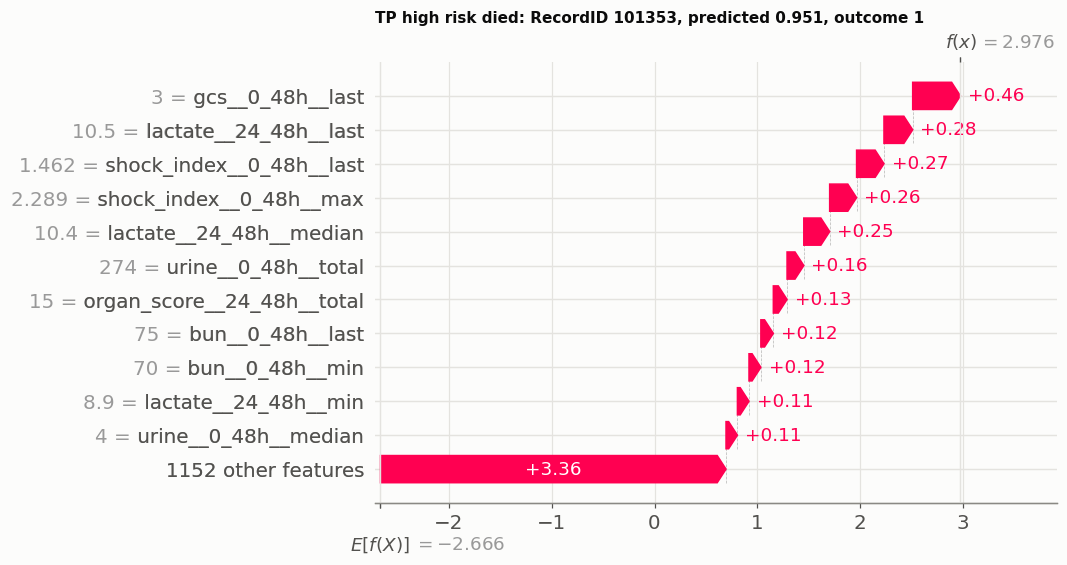

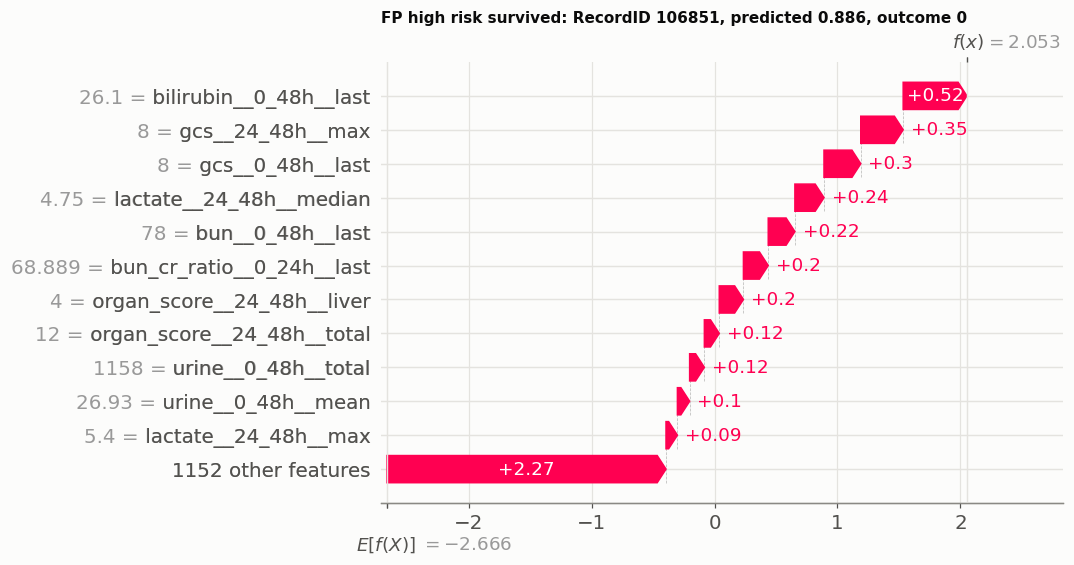

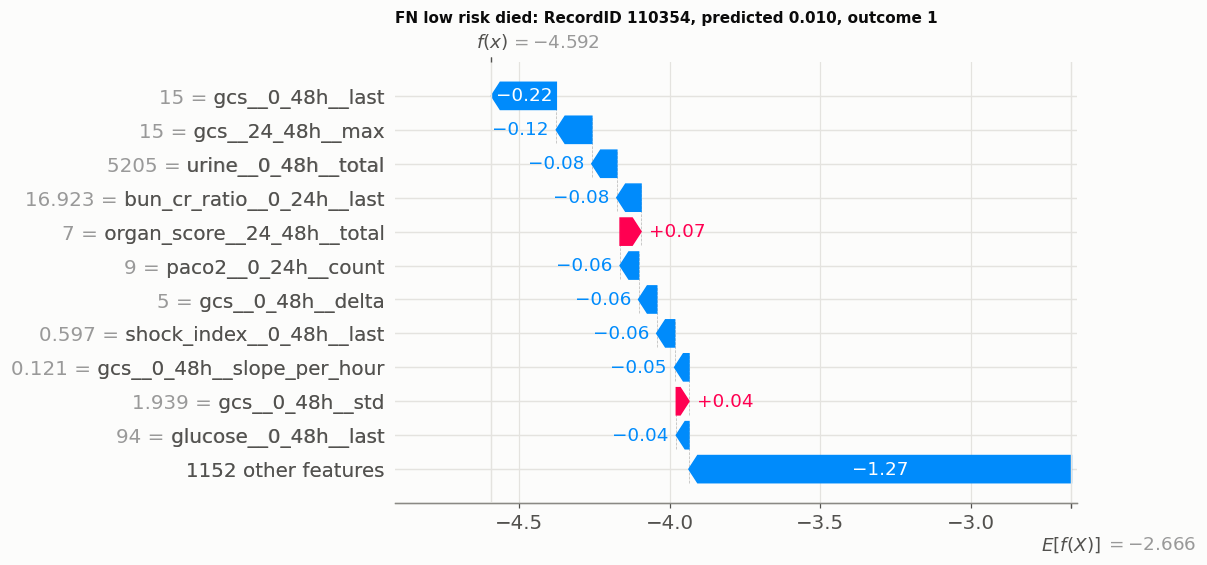

,case,RecordID,predicted,feature,value,SHAP (log-odds)
0,TP_high_risk_died,101353,0.951,gcs__0_48h__last,3,0.464
1,TP_high_risk_died,101353,0.951,lactate__24_48h__last,10.5,0.279
2,TP_high_risk_died,101353,0.951,shock_index__0_48h__last,1.462,0.266
3,TP_high_risk_died,101353,0.951,shock_index__0_48h__max,2.289,0.262
4,TP_high_risk_died,101353,0.951,lactate__24_48h__median,10.4,0.252
5,TP_high_risk_died,101353,0.951,urine__0_48h__total,274,0.163
6,FP_high_risk_survived,106851,0.886,bilirubin__0_48h__last,26.1,0.519
7,FP_high_risk_survived,106851,0.886,gcs__24_48h__max,8,0.345
8,FP_high_risk_survived,106851,0.886,gcs__0_48h__last,8,0.299
9,FP_high_risk_survived,106851,0.886,lactate__24_48h__median,4.75,0.237


In [26]:
cand = {"TP_high_risk_died": np.where((p4_te > 0.5) & (y_te == 1))[0],
        "FP_high_risk_survived": np.where((p4_te > 0.5) & (y_te == 0))[0],
        "FN_low_risk_died": np.where((p4_te < 0.3) & (y_te == 1))[0]}
cases = {"TP_high_risk_died": cand["TP_high_risk_died"][np.argmax(p4_te[cand["TP_high_risk_died"]])],
         "FP_high_risk_survived": cand["FP_high_risk_survived"][np.argmax(p4_te[cand["FP_high_risk_survived"]])],
         "FN_low_risk_died": cand["FN_low_risk_died"][np.argmin(p4_te[cand["FN_low_risk_died"]])]}
case_rows = []
Xt_np, tcols = Xt_te.to_numpy(), list(Xt_te.columns)
for label, i in cases.items():
    exp = shap.Explanation(values=shap_te[i], base_values=base_te[i], data=Xt_np[i], feature_names=tcols)
    shap.plots.waterfall(exp, max_display=12, show=False)
    fig = plt.gcf(); fig.set_size_inches(8, 5.2)
    plt.title(f"{label.replace('_', ' ')}: RecordID {ids_te[i]}, predicted {p4_te[i]:.3f}, outcome {y_te[i]}",
              loc="left", fontsize=10, fontweight="bold")
    savefig(fig, "task2", f"B9_shap_waterfall_{label}")
    top = np.argsort(-np.abs(shap_te[i]))[:6]
    case_rows += [{"case": label, "RecordID": ids_te[i], "predicted": p4_te[i], "feature": tcols[j],
                   "value": Xt_np[i, j], "SHAP (log-odds)": shap_te[i, j]} for j in top]
pd.DataFrame(case_rows).round(3)

## B10 The 2012 challenge metric (validation only)

The 2012 challenge scored entries on min(Se, PPV). Our operating point was chosen for recall ≈ 0.80, on clinical grounds, which does not maximise that metric. Here we sweep the threshold on **validation only**; test is not re-thresholded, because that would be a second look.

In [27]:
thr_grid = np.linspace(0.01, 0.99, 197)
mse = np.array([min_se_ppv(y_va, (p4_va >= t).astype(int)) for t in thr_grid])
t_best = thr_grid[mse.argmax()]
m_best, m_rec = compute_metrics(y_va, p4_va, threshold=t_best), compute_metrics(y_va, p4_va, threshold=r4["threshold"])
pd.DataFrame({"recall-0.80 point (ours)": m_rec, "min(Se,PPV)-optimal point": m_best}).T.assign(
    threshold=[r4["threshold"], t_best])[["threshold", "sensitivity", "ppv", "specificity", "min_se_ppv"]].round(3)

,threshold,sensitivity,ppv,specificity,min_se_ppv
recall-0.80 point (ours),0.144,0.801,0.386,0.789,0.386
"min(Se,PPV)-optimal point",0.32,0.523,0.528,0.922,0.523


For reference, on the challenge's own hidden test sets (B + C) the SAPS-I benchmark scored 0.313 and the winning entry 0.535. Those are different test sets, so the comparison is approximate.

At the validation-optimal threshold of 0.275, min(Se, PPV) is 0.531, with Se 0.535 and PPV 0.531. That would have been competitive, but it gives up a third of the sensitivity (0.80 → 0.54). This project's clinical framing rejects that trade: a missed death costs more than an extra review.

## B11 Discussion

**Headline.** On the frozen test set of 1,800 stays (256 deaths), CatBoost using the 1,163 features retained by the train-fitted filter achieved **AUROC 0.864 [0.842, 0.884]** and **AUPRC 0.570 [0.519, 0.625]**. Test prevalence was 0.142, so AUPRC was about 4.0 times the no-skill reference. The model used measurements from the first 48 h to predict in-hospital death; it does not use length of stay.

**Reading the model ladder.** The eight-feature L3-revised logistic model reached AUROC 0.815 and AUPRC 0.478. The single-feature BUN maximum reached AUROC 0.664 and AUPRC 0.236. SAPS-I and SOFA reached AUROC 0.652 and 0.629, respectively, on the available-score subsets. On those same patients, CatBoost reached AUROC 0.868 and 0.866. The model improves discrimination over the bedside scores, while its added complexity should be weighed against the limits below.

**Clinical interpretation.** CatBoost's largest mean absolute SHAP contributions came from last GCS in the first 48 h, age, maximum GCS in hours 24?48, the derived day-two organ-score total, total urine, and derived shock-index and BUN/creatinine features. These are associations used by the fitted model, not causal effects. GCS may reflect sedation and documentation practice as well as neurological status; the derived scores are proxies based on the available variables.

**Operating point and calibration.** The decision threshold was selected on validation for approximately 0.80 sensitivity and then applied to test (test threshold 0.144; sensitivity 0.801, PPV 0.386). Test Brier score was 0.0869 versus 0.1220 for a constant-prevalence predictor. The calibration table still shows local over- and under-estimation, so individual probabilities need calibration and external validation before clinical use.

**Limitations.** This is internal validation on one public dataset. The source cohort already requires ICU stays of at least 48 h, and the target includes deaths after ICU discharge. Fairness by sex or age band was not assessed. The 167 stays with `Length_of_stay = -1` remain in the cohort because LOS is neither an input nor the target; all 12,000 stays are represented in the split and analysis.


---
# Part C · Summary and saved artefacts

| | **Task 1: SOFA Trajectory Forecasting** | **Task 2: In-Hospital Mortality Prediction** |
|---|---|---|
| Task focus | *6-hour-ahead forecast of the rolling 24-hour rule-based proxy-SOFA score* | *In-hospital mortality prediction from the first 48 hours after ICU admission* |
| Best model | ordinal decomposition (filter → HistGB threshold classifiers) | filter → CatBoost (1,159 features) |
| Test result | total-SOFA MAE 0.568 vs persistence 0.726 (mean of 4 horizons) | AUROC 0.864 [0.842, 0.884], AUPRC 0.570 [0.519, 0.625] |
| Simple baseline | persistence; beaten at 4/4 horizons by 4 of 5 families | SAPS-I 0.652, SOFA 0.629; L3-revised logistic 0.815 |
| Secondary result | >=2-point rolling 24-hour proxy-SOFA rise label AUPRC 0.315 (about 7x no-skill); top 10% of checkpoints capture 51% of positive labels | SHAP highlights GCS, age, renal and derived severity features |

**What the data-preparation work established, across both tasks:**

* **Leakage-safe by construction.**
  * Each split is made by stay before any statistic is fitted.
  * Every imputer, encoder, scaler, filter and resampler sits inside a pipeline fitted on training rows.
  * Selection steps are nested inside CV.
  * The outcome columns never enter X.
* **Outlier screening and filtering are cheap and safe.** Implausible values became missing; the filter removed 12–24 % of columns with no measurable accuracy cost.
* **Class imbalance needed no resampling.** With AUPRC as the selection metric, plain fitting matched or beat class weights, SMOTE and under-sampling in both tasks. Re-weighting and resampling only distorted the probabilities, so the simplest strategy was kept.
* **Feature engineering beat model complexity.**
  * Choosing the right summary statistic (last vs minimum GCS) was worth more than any modelling change on the ladder.
  * Clinically derived ratios and organ scores rank among task 2's most-used features.
  * The ordinal reformulation, not a more complex learner, gave task 1 its best result.

**Shared limits:** one public dataset, internal validation only, no medication data, and probabilities that need calibration before clinical use.

The cell below lists every artefact this notebook reads or writes:

* `preprocessed/`: pre-processing outputs.
* `trained_models/`: the fitted pipelines (pre-processing and model saved together) and the task 1 model specification.
* `results/`: figures, result tables and experiment logs.

### Hyperparameter tuning log

The cell below writes **`results/hyperparameter_tuning_log.md`** from the tuning records saved during this run. It documents, for both tasks:

* every search space;
* every configuration that was tried, with its validation or CV score, and the selected one marked;
* the class-imbalance and feature-filter choices, and the top-*k* selection;
* what was deliberately left untuned, and why.

In [ ]:
from src.shared.tuning_log import task1_section, task2_section, write_tuning_log

t1_spaces = {"ordinal (per threshold)": t1m.ordinal.GRID, "linear: Ridge": t1m.linear.RIDGE_GRID,
             "linear: logistic (rolling 24-hour proxy-SOFA ≥2-point rise)": t1m.linear.LOGISTIC_GRID, "histgb: regressor": t1m.REGRESSOR_GRID,
             "histgb: rolling 24-hour proxy-SOFA ≥2-point rise": t1m.CLASSIFIER_GRID, "catboost: regressor": t1m.catboost_model.REGRESSOR_GRID,
             "catboost: rolling 24-hour proxy-SOFA ≥2-point rise": t1m.catboost_model.CLASSIFIER_GRID,
             "lightgbm: regressor": t1m.lightgbm_model.REGRESSOR_GRID,
             "lightgbm: rolling 24-hour proxy-SOFA ≥2-point rise": t1m.lightgbm_model.CLASSIFIER_GRID, "histgb_absolute": t1m.REGRESSOR_GRID}
xgb_c = xgb_candidates.assign(selected=lambda d: np.where(d["rank"] == 1, "★", ""))
cb_c = cb_candidates.assign(selected=["★"] + [""] * (len(cb_candidates) - 1))
log_path = write_tuning_log(
    ROOT / "results" / "hyperparameter_tuning_log.md",
    task1_section(spec, t1_spaces),
    task2_section(imb_lr=imb_lr, imb_lr_kept=IMB_LR, l3_variants=pd.DataFrame(l3_variant_rows).T,
                  imb_xgb=imb_xgb, imb_xgb_kept=IMB_XGB, filter_check=filt_abl, xgb_space=XGB_SPACE,
                  xgb_candidates=xgb_c, xgb_best=BEST_XGB, xgb_search_meta=search_log,
                  topk=topk_cv.groupby("k")[["AUROC"]].mean().join(topk_tbl), k_chosen=K_CHOSEN,
                  n_filtered=Xf_tr.shape[1], cb_space=CB_SPACE, cb_candidates=cb_c, cb_params=CB_PARAMS,
                  cb_trees=int(cb_pipe.named_steps["model"].tree_count_), selected_model=SELECTED_MODEL))
n_t1 = sum(len(r) for f in spec["families"].values() for g in f["validation_grids"].values()
           for r in (g.values() if isinstance(g, dict) else [g]))
print(f"wrote {log_path.relative_to(ROOT)}: {n_t1} task 1 grid fits + {len(xgb_candidates)} XGBoost and "
      f"{len(cb_candidates)} CatBoost search candidates, all with their selection scores")

In [29]:
def tree(path, depth=0, max_files=8):
    files = sorted(p for p in path.iterdir() if p.is_file())
    for p in files[:max_files]:
        print("    " * depth + f"{p.name}  ({p.stat().st_size / 1e6:.2f} MB)")
    if len(files) > max_files:
        print("    " * depth + f"... and {len(files) - max_files} more files")
    for d in sorted(p for p in path.iterdir() if p.is_dir()):
        print("    " * depth + f"{d.name}/")
        tree(d, depth + 1, max_files)


for top in ("preprocessed", "trained_models", "results"):
    print(f"{top}/"); tree(ROOT / top, 1)

preprocessed/
    task1_sofa/
        features.csv.gz  (25.31 MB)
        qc_report.md  (0.00 MB)
        records_clean.joblib  (22.07 MB)
        sofa_day_scores.csv  (0.70 MB)
        sofa_scores_extended.csv  (1.68 MB)
        splits.csv  (0.30 MB)
        targets.csv  (4.34 MB)
    task2_mortality/
        derived_features.csv.gz  (1.35 MB)
        feature_dictionary.csv  (0.58 MB)
        feature_missingness.csv  (0.08 MB)
        independent_verification.json  (0.00 MB)
        labels_and_baselines.csv  (0.34 MB)
        labels_and_splits.csv  (0.19 MB)
        manifest.sha256  (0.00 MB)
        parameter_distributions.csv  (0.00 MB)
        ... and 10 more files
trained_models/
    task1_sofa/
        model_spec.json  (0.09 MB)
        catboost/
            axis_cardio.joblib  (0.39 MB)
            axis_coag.joblib  (0.39 MB)
            axis_liver.joblib  (0.15 MB)
            axis_neuro.joblib  (0.39 MB)
            axis_renal.joblib  (0.39 MB)
            axis_resp.joblib  (0